# $n(\mu)$ for pQCD: BUQEYE truncation error

## Author: Alexandra Semposki

---

## Setting up the calculation

First, we import all necessary packages.

In [1]:
# import packages
%load_ext autoreload
%autoreload 2

import gsum as gm
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, MaxNLocator
import numpy as np
import numdifftools as ndt
import scipy.stats as stats
from scipy.optimize import fsolve
import os
from IPython.display import Image
import sys
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

sys.path.append('../src/neutron_rich_bmm')
sys.path.append('../data')

import scipy.integrate as sc
import scipy.optimize as opt
from scipy.interpolate import interp1d
from collections import defaultdict

from pqcd_reworked import PQCD, PQCDDens
from truncation_error import Truncation

from scripts import *
setup_rc_params()

%matplotlib inline

edgewidth = 0.3

sys.path.append('../nuclear-matter-convergence/')
from nuclear_matter.graphs import *
from nuclear_matter import lighten_color

In [2]:
# define order list now
orders = [0,1,2]

# plotting assistance
order_labels = ['LO', 'NLO', 'N$^{2}$LO', 'N$^{3}$LO']
color_list = ['Oranges', 'Greens', 'Blues', 'Reds', 'Purples', 'Greys']
cmaps = [plt.get_cmap(name) for name in color_list[:len(orders)]]
colors = [cmap(0.65 - 0.1 * (i == 0)) for i, cmap in enumerate(cmaps)]
light_colors = [lighten_color(color, 0.55) for color in colors]
dark_colors = [lighten_color(color, 1.5) for color in colors]

---

## Calculation of $P(\mu)$ <a id="calc_p_mu"></a>

Here we calculate the scaled pressure in terms of the quark chemical potential $\mu_q \equiv \mu$, since we will be needing this quantity for the model mixing step of this work. 

We begin by looking at the coefficients of the $P(\mu)$ series to see what the interpolation will look like.

In [3]:
n0 = 0.164   # fm-3

In [4]:
# first choose a chemical potential range (the one below corresponds to the number density
# that we will be using later)
x = np.linspace(0.4, 1.32, 250)  # mu_q
x_B = 3.0*x  # mu_B

X = x[:, None]  # make a 2D version of x to match the input data structure from scikit learn
n_orders = 3    # Here we examine the case where we have info on two non-trivial orders (1,2)
orders = np.arange(0, n_orders)

# try only using the NLO, N2LO coefficients
excluded = [0]
orders_mask = ~ np.isin(orders, excluded)   # masking orders to exclude them from training

# call the PQCD class from the pqcd_reworked.py file
pqcd = PQCD(X=1,Nf=3)

# define the coefficients using the coefficient functions in 
# the pQCD class 

coeffs = np.array([pqcd.c_0(x), pqcd.c_1(x), pqcd.c_2(x)]).T 

Now we call the `Truncation()` class, and send it the chemical potential, number of orders, order array, function for yref (for us, found in the pQCD class), expansion parameter (for us, also found in the pQCD class), coefficient array, and the mask such that we only train on the selected orders. 

In [5]:
# using the classes to get the results
# employs gsum for interpolation and truncation GPs
# send the orders and mask into the truncation class
trunc = Truncation(x, x_FG=None, norders=3, orders=orders, yref=pqcd.yref, \
                   expQ=pqcd.expQ, coeffs=coeffs, mask=orders_mask)

### Now we plot the curves and coefficients.

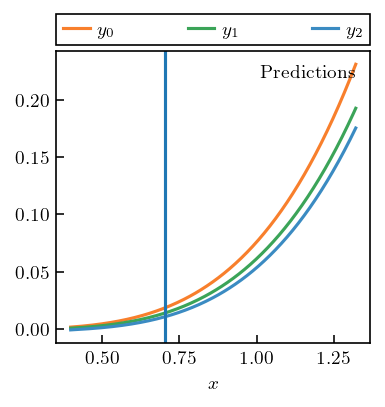

In [6]:
top_legend_kwargs = dict(
    loc='lower left',
    bbox_to_anchor=(0, 1.02, 1, 0.5), ncol=4,
    borderpad=0.37,
    labelspacing=0.,
    handlelength=1.4,
    handletextpad=0.4, borderaxespad=0,
    edgecolor='k',
    mode='expand',
    fancybox=False
)

fig, ax = plt.subplots(1, 1, figsize=(2.45, 2.6))

for i, curve in enumerate(trunc.data.T):
    ax.plot(x, curve, label=r'$y_{}$'.format(i), c=colors[i])

ax.text(0.95, 0.95, 'Predictions', ha='right', va='top',
        transform=ax.transAxes)

legend = ax.legend(**top_legend_kwargs)

# Format
ax.set_xlabel(r'$x$')
ax.axvline(0.705)
plt.show()

## $n(\mu)$ BUQEYE calculation

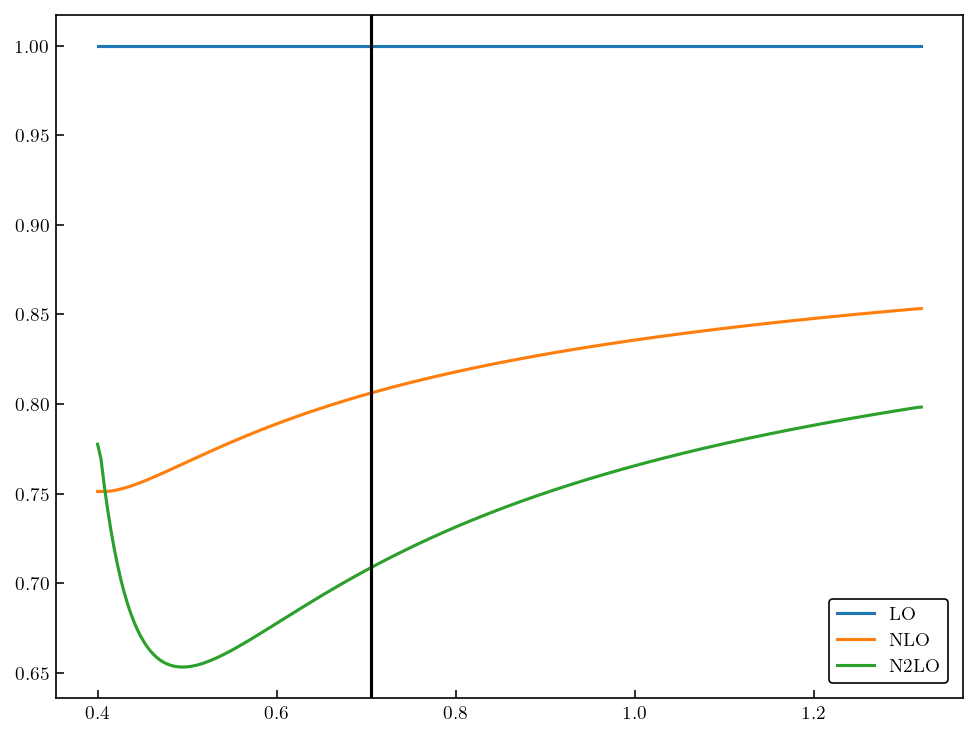

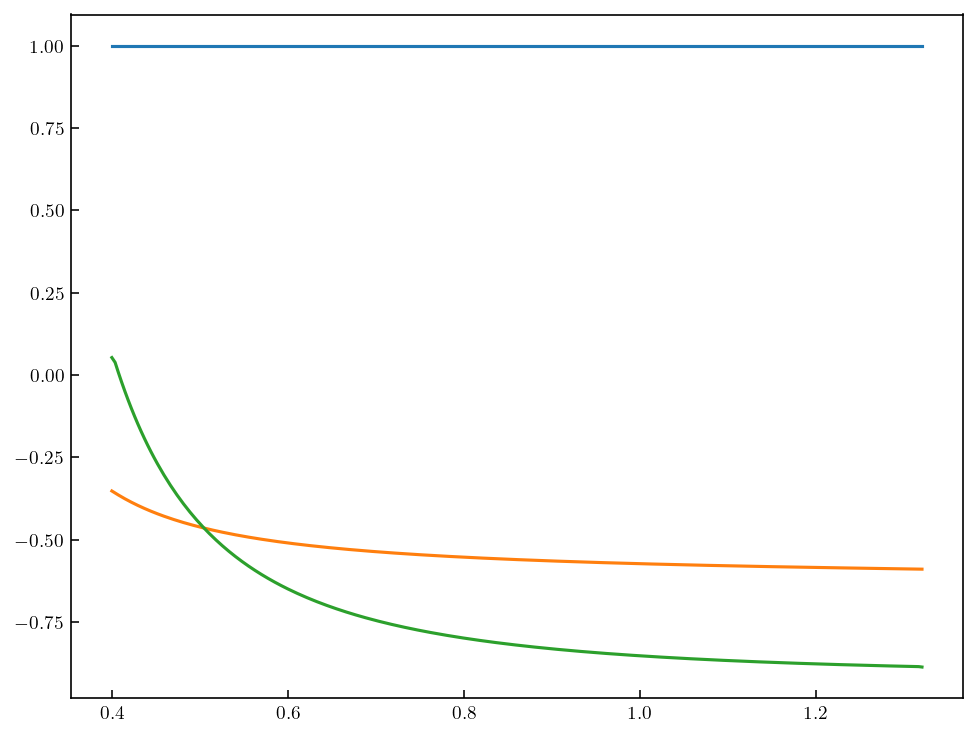

In [11]:
# take derivatives of this quantity wrt x (full, including the FG scale and Q)
n_deriv_FG = np.gradient(trunc.data.T[0,:], x)
n_deriv_NLO = np.gradient(trunc.data.T[1,:], x)
n_deriv_N2LO = np.gradient(trunc.data.T[2,:], x)

# full derivative of alpha_s wrt mu via numdifftools
dalphadmu = np.gradient(pqcd.alpha_s(x, loop=2), x)

# the expansion parameter
#numdifftools one
def expQdens(mu):
    #dalphadmu = ndt.Derivative(pqcd.alpha_s, step=0.00001)
    #expandQ = 3.0 * dalphadmu(mu) / np.pi
    expandQ = 3.0 * pqcd.alpha_s(mu) / np.pi
    return expandQ[:,0]

def n_FG_mu(mu):
    n_FG = 3 * mu**3.0 / (np.pi**2.0)
    return n_FG[:,0]

# calculate coefficients here first
c0 = n_deriv_FG/n_deriv_FG
c1 = ((n_deriv_NLO/n_deriv_FG) - 1.0) * 1.0/expQdens(X)
c2 = ((n_deriv_N2LO/n_deriv_FG) - 1.0 - c1*expQdens(X))*(1.0/expQdens(X)**2.0)

plt.plot(x, n_deriv_FG/n_deriv_FG, label='LO')
plt.plot(x, n_deriv_NLO/n_deriv_FG, label='NLO')
plt.plot(x, n_deriv_N2LO/n_deriv_FG, label='N2LO')
plt.axvline(x=0.705, color='black')
plt.legend()
plt.show()

# coefficients plot (check for naturalness)
plt.plot(x, c0)
plt.plot(x, c1)
plt.plot(x, c2)
plt.show()

# now we need the coefficients to feed to the Truncation class (try to feed)
coeffsdensity = np.array([c0, c1, c2]).T

# feed the new GP class
truncdensity = Truncation(x, x_FG=None, norders=3, orders=orders, yref=n_FG_mu, \
                   expQ=expQdens, coeffs=coeffsdensity, mask=orders_mask)

[[<matplotlib.lines.Line2D at 0x15d03b4c0>],

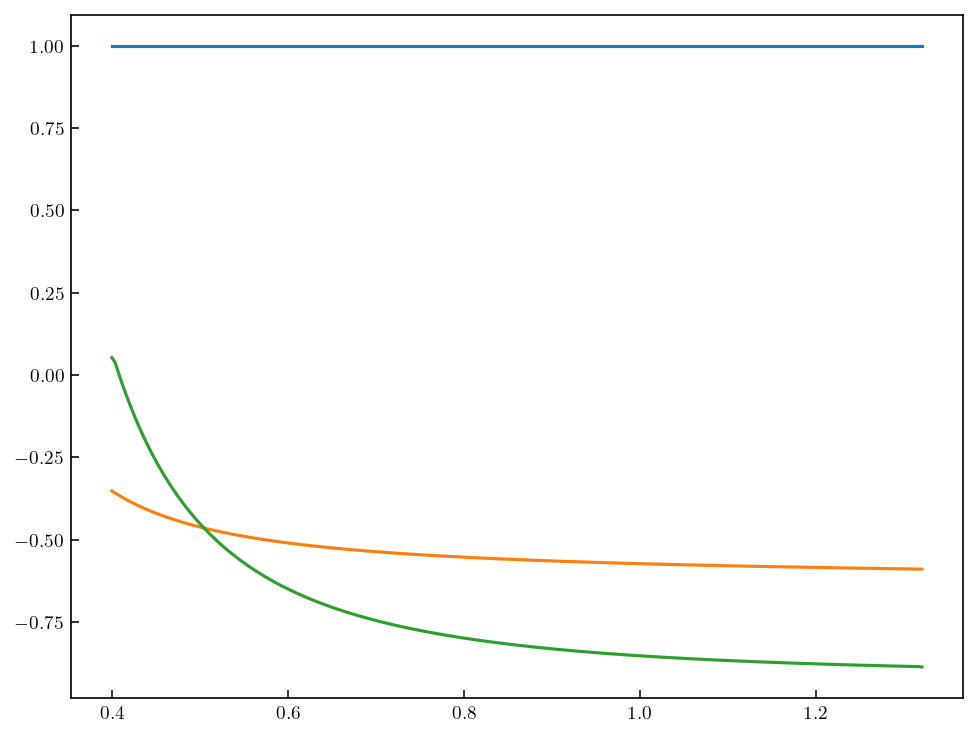

In [12]:
[plt.plot(x, truncdensity.coeffs[:,i]) for i in range(3)]

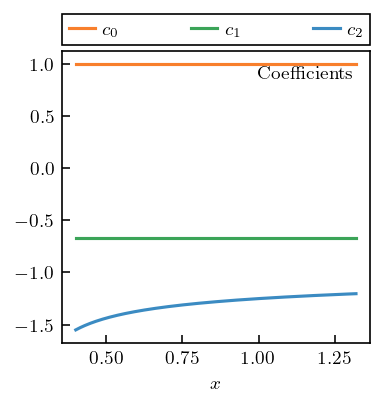

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(2.45, 2.6))

for i,n in enumerate(orders):
    ax.plot(x, trunc.coeffs[:, i], label=r'$c_{}$'.format(i), c=colors[i])

ax.text(0.95, 0.95, 'Coefficients', ha='right', va='top',
           transform=ax.transAxes)

legend = ax.legend(**top_legend_kwargs)

# Format
ax.set_xlabel(r'$x$')
plt.show()

Now we fit and predict using the GP class in `gsum` so that we can see what the interpolation will do once we call the actual `TruncationGP` class in `gsum`.

In [16]:
# now fit and predict with the GP (this is directly on the coefficients, so our diagnostics)
pred, std, underlying_std = trunc.gp_interpolation(center=0.0, sd=1.0)

RBF(length_scale=8.33)
0.9371648534276845


RBF(length_scale=1.22)
0.7464942118709694


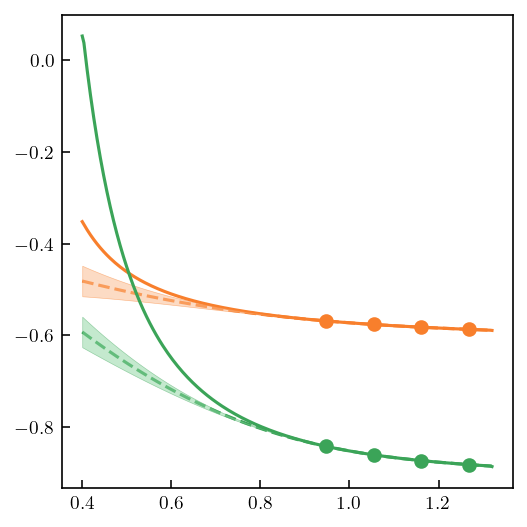

In [28]:
preddens, stddens, underlying_stddens = truncdensity.gp_interpolation(center=0.0, sd=1.0)

fig, ax = plt.subplots(figsize=(3.4, 3.4), dpi=150)

# plot this
for i, n in enumerate(orders[1:]):
    ax.plot(x, preddens[:, i], c=colors[i], zorder=i-5, ls='--')
    ax.plot(x, truncdensity.coeffs_trunc[:, i], c=colors[i], zorder=i-5)
  #  ax.plot(x, trunc.coeffs[:, i], c=colors[i], zorder=i-5)
    ax.plot(x[truncdensity.mask], truncdensity.coeffs_trunc[truncdensity.mask, i], c=colors[i], zorder=i-5, ls='', marker='o',
            label=r'$c_{}$'.format(n))
 #   ax.plot(x[trunc.mask], trunc.coeffs[trunc.mask, i], c=colors[i], zorder=i-5, ls='', marker='o',
 #         label=r'$c_{}$'.format(n))
    ax.fill_between(x, preddens[:, i] + 2*stddens, preddens[:, i] - 2*stddens, zorder=i-5,
                     facecolor=light_colors[i], edgecolor=colors[i], lw=edgewidth, alpha=0.5)

Now we plot the coefficients that we trained on, and the overlaid GP results, so that we can see how the training did.

RBF(length_scale=8.33)
0.9371648534276845
0.9680727521357496


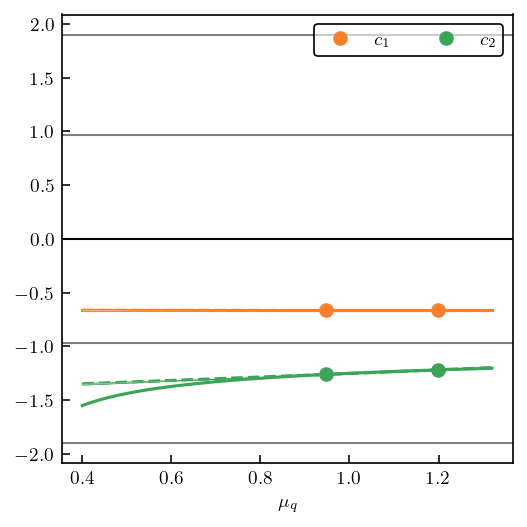

In [29]:
fig, ax = plt.subplots(figsize=(3.4, 3.4), dpi=150)
for i, n in enumerate(orders[1:]):
    ax.plot(x, pred[:, i], c=colors[i], zorder=i-5, ls='--')
    ax.plot(x, trunc.coeffs_trunc[:, i], c=colors[i], zorder=i-5)
  #  ax.plot(x, trunc.coeffs[:, i], c=colors[i], zorder=i-5)
    ax.plot(x[trunc.mask], trunc.coeffs_trunc[trunc.mask, i], c=colors[i], zorder=i-5, ls='', marker='o',
            label=r'$c_{}$'.format(n))
 #   ax.plot(x[trunc.mask], trunc.coeffs[trunc.mask, i], c=colors[i], zorder=i-5, ls='', marker='o',
 #         label=r'$c_{}$'.format(n))
    ax.fill_between(x, pred[:, i] + 2*std, pred[:, i] - 2*std, zorder=i-5,
                     facecolor=light_colors[i], edgecolor=colors[i], lw=edgewidth, alpha=1)

print(trunc.gp_interp.kernel_)
print(trunc.gp_interp.cov_factor_)
print(np.sqrt(trunc.gp_interp.cov_factor_))

# Format
ax.axhline(1.96*underlying_std, 0, 1, c='gray', zorder=-10, lw=1)
ax.axhline(-1.96*underlying_std, 0, 1, c='gray', zorder=-10, lw=1)
ax.axhline(1.0*underlying_std, 0, 1, c='gray', zorder=-10, lw=1)
ax.axhline(-1.0*underlying_std, 0, 1, c='gray', zorder=-10, lw=1)
ax.axhline(0, 0, 1, c='k', zorder=-10, lw=1)
ax.set_xlabel(r'$\mu_{q}$')
ax.tick_params(which='minor', bottom=True, top=False)
ax.legend(ncol=2, borderaxespad=0.5, borderpad=0.4)

We then build the order-by-order data for the truncation GP to construct the truncation error bands at each order. Then we call the `truncation_error.py` function `uncertainties` and send it the data, expansion parameter, value for $y_{\textrm{ref}}$, and a very small nugget to help the Cholesky decomposition when fitting. We then print the lengthscale and value of the marginal variance, $\bar{c}^{2}$.

RBF(length_scale=1.22)
1e-09
0.7483176670788925
(250, 3)


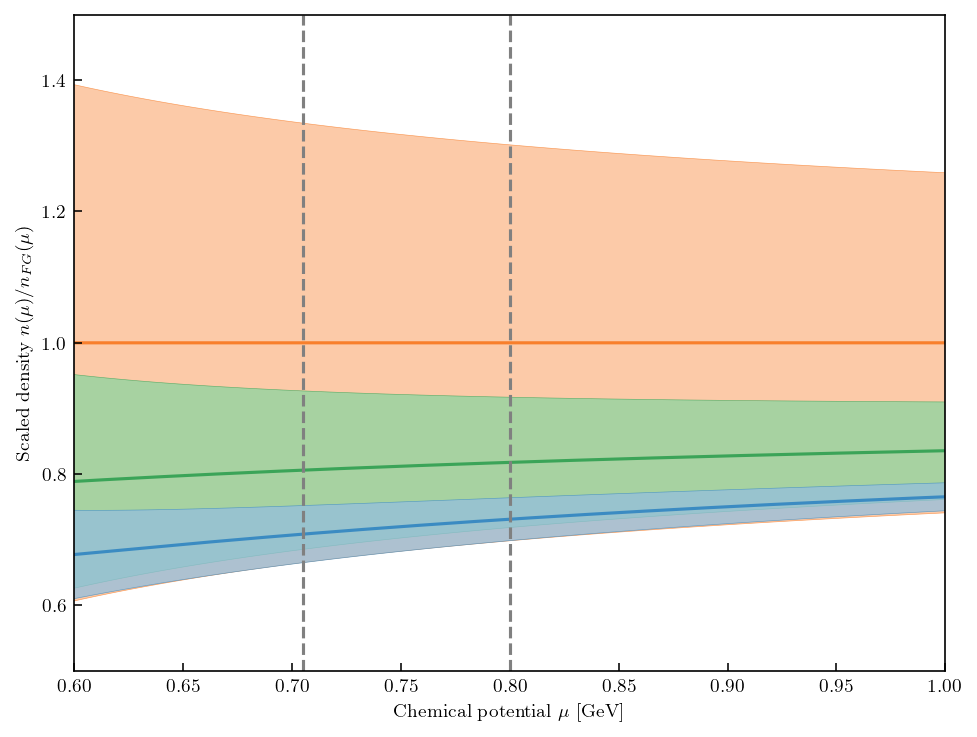

Size of NLO band:  0.24141623179775362
Size of N2LO band:  0.08709251580278898
Difference between the two bands:  0.15432371599496464
% difference between the two bands:  46.97704920254298


In [33]:
# ok now feed the uncertainties function
data_0 = pqcd.n_FG_mu(x) * c0
data_1 = pqcd.n_FG_mu(x) * (c0 + c1*expQdens(X))
data_2 = pqcd.n_FG_mu(x) * (c0 + c1*expQdens(X) + c2*expQdens(X)**2.0)
# compile
datadens = np.array([data_0, data_1, data_2]).T

# feed
datadens, coeffsdens, stddensnow, cov_1dens = truncdensity.uncertainties(data=datadens, expQ=expQdens, yref=n_FG_mu, sd=1.0, \
                                        excluded=[0], nugget=1e-09)

print(truncdensity.trunc_gp.coeffs_process.cov_factor_)
print(datadens.shape)

# plot the results
for i in range(3):
    plt.plot(x, datadens[:,i]/n_deriv_FG, color=colors[i], zorder=i)
    plt.fill_between(x, (datadens[:, i] + stddensnow[:,i])/n_deriv_FG, (datadens[:, i] - stddensnow[:,i])/n_deriv_FG,
                        zorder=i-1, facecolor=light_colors[i], edgecolor=colors[i], lw=edgewidth, alpha=0.75)
plt.xlim(0.6, 1.0)
plt.ylim(0.5,1.5)
plt.xlabel(r'Chemical potential $\mu$ [GeV]')
plt.ylabel(r'Scaled density $n(\mu)/n_{FG}(\mu)$')

plt.axvline(x=0.705, color='grey', linestyle='dashed')
plt.axvline(x=0.8, color='grey', linestyle='dashed')
plt.show()

# calculate the size of the truncation errors for 0.705 GeV in NLO and N2LO
interp_NLO_upper = interp1d(x[50:], (datadens[50:, 1] + stddensnow[50:,1])/n_deriv_FG[50:], kind='cubic')
interp_N2LO_upper = interp1d(x[50:], (datadens[50:,2] + stddensnow[50:,2])/n_deriv_FG[50:], kind='cubic')
interp_NLO_lower = interp1d(x[50:], (datadens[50:, 1] - stddensnow[50:,1])/n_deriv_FG[50:], kind='cubic')
interp_N2LO_lower = interp1d(x[50:], (datadens[50:,2] - stddensnow[50:,2])/n_deriv_FG[50:], kind='cubic')
NLO_20_upper = interp_NLO_upper(0.705)
N2LO_20_upper = interp_N2LO_upper(0.705)
NLO_20_lower = interp_NLO_lower(0.705)
N2LO_20_lower = interp_N2LO_lower(0.705)

difference_NLO = NLO_20_upper - NLO_20_lower #(total size of band)
difference_N2LO = N2LO_20_upper - N2LO_20_lower 
#percent_diff = 100*(np.abs(NLO_20 - N2LO_20)/(NLO_20 + N2LO_20))

print('Size of NLO band: ', difference_NLO)
print('Size of N2LO band: ', difference_N2LO)

# percent differences between size of bands at 0.705 GeV
print('Difference between the two bands: ', difference_NLO-difference_N2LO)
print('% difference between the two bands: ', \
      100*np.abs(difference_NLO-difference_N2LO)/(difference_NLO+difference_N2LO))

In [122]:
# data order-by-order P(mu) calculation
data_0 = pqcd.yref(X) * pqcd.c_0(x) 
data_1 = pqcd.yref(X) * (pqcd.c_0(x) + pqcd.c_1(x)*pqcd.expQ(X))
data_2 = pqcd.yref(X) * (pqcd.c_0(x) + pqcd.c_1(x)*pqcd.expQ(X) + pqcd.c_2(x)*pqcd.expQ(X)**2.0)

# compile the orders
data = np.array([data_0, data_1, data_2]).T

# feed to the TruncationGP class and get back the truncation errors (excluding c_0)
data, coeffs, std, cov_1 = trunc.uncertainties(data=data, expQ=pqcd.expQ, yref=pqcd.yref, sd=1.0, \
                                        excluded=[0], nugget=1e-09)
print(trunc.trunc_gp.coeffs_process.cov_factor_)

print(data.shape)

RBF(length_scale=9.4)
1e-09
1.4939966729972025
(250, 3)


Now we plot the results from the $P(\mu)$ truncation error analysis.

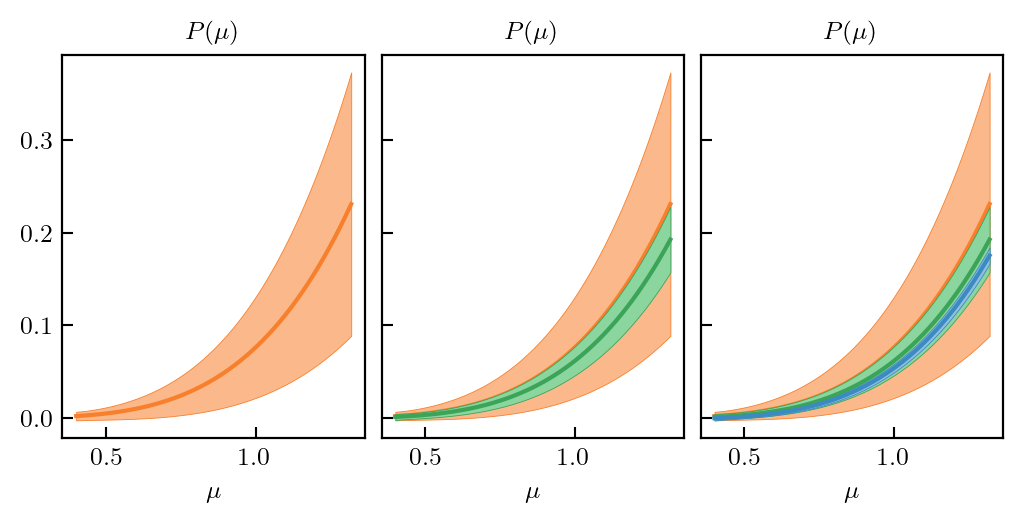

In [123]:
# plot the results here to check the class
fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(5, 2.5), dpi=200)

for i, n in enumerate(orders):
    for j in range(i, 3):
        ax = axes.ravel()[j]
        ax.plot(x, data[:, i], zorder=i, c=colors[i])
        ax.fill_between(x, data[:, i] + 1.96*std[:,i], data[:, i] - 1.96*std[:,i],
                        zorder=i-1, facecolor=light_colors[i], edgecolor=colors[i], lw=edgewidth)
    ax = axes.ravel()[i]
    ax.set_xlabel(r'$\mu$')
    ax.set_title(r'$P(\mu)$')

Let's now scale the pressure results by the $y_{\textrm{ref}}$ result at each density---the Fermi gas pressure, $P_{FG}(\mu)$.

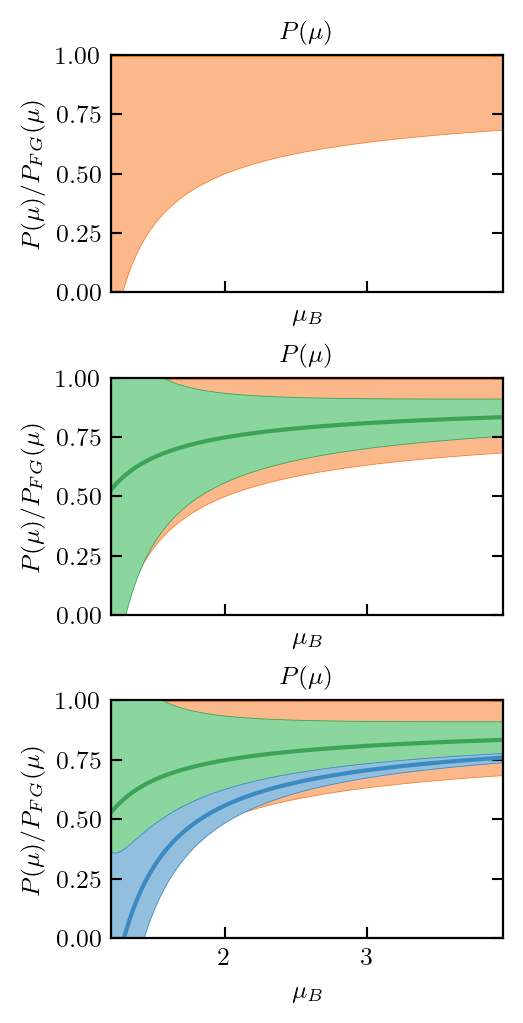

In [124]:
fig, axes = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(2.5, 5), dpi=200)

for i,n in enumerate(orders):
    for j in range(i, 3):
        ax = axes.ravel()[j]
        ax.plot(x_B, data[:, i]/pqcd.yref(X), zorder=i, c=colors[i])
        ax.fill_between(x_B, (data[:, i] + 1.0*std[:,i])/pqcd.yref(X), (data[:, i] - 1.0*std[:,i])/pqcd.yref(X),
                        zorder=i-1, facecolor=light_colors[i], edgecolor=colors[i], lw=edgewidth)
    ax = axes.ravel()[i]
    ax.set_ylim(0,1)
    ax.set_xlim(min(x_B), max(x_B))
    ax.set_xlabel(r'$\mu_{B}$')
    ax.set_ylabel(r'$P(\mu)/P_{FG}(\mu)$')
    ax.set_title(r'$P(\mu)$')
    ax.tick_params(right=True)

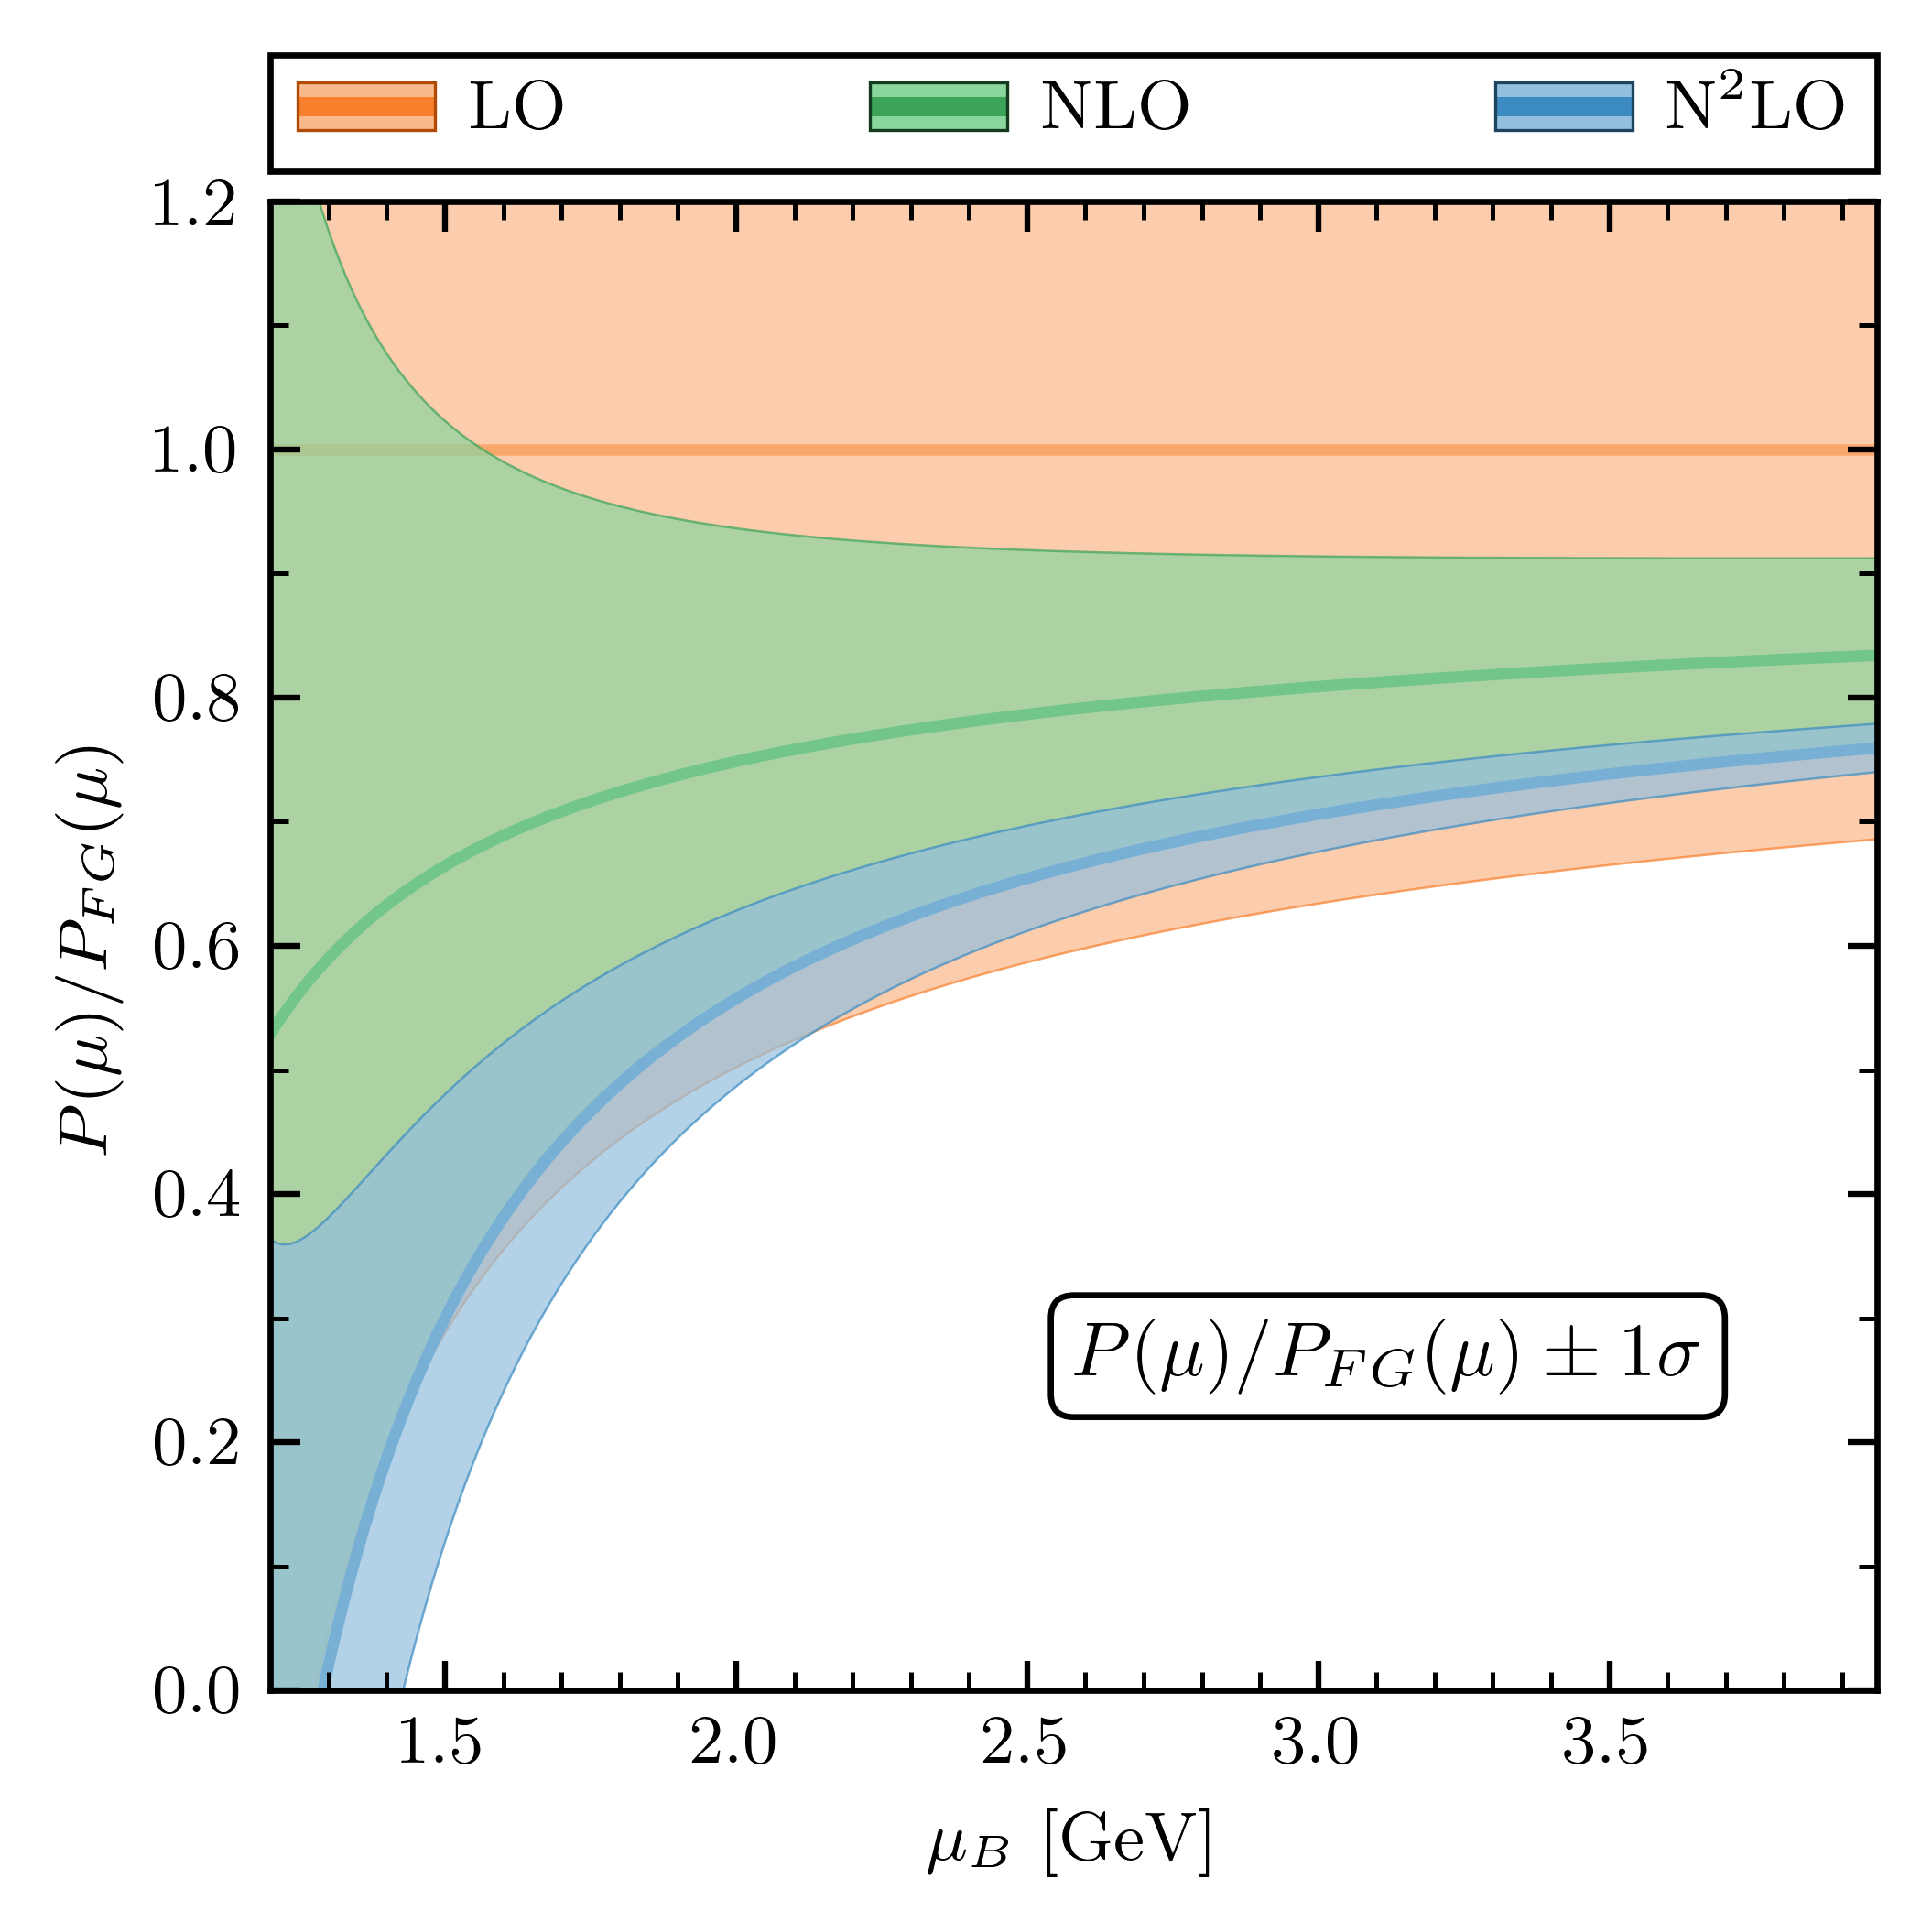

In [125]:
# Fig. 3 in our paper
labels = [r'LO', r'NLO', r'N$^{2}$LO']

fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(3.4, 3.4), dpi=600)
for i in range(3):
    ax.plot(3.0 * x, data[:, i]/pqcd.yref(X), zorder=i-1, c=colors[i])
    ax.fill_between(3.0 * x, (data[:, i] + 1.0*std[:,i])/pqcd.yref(X), \
                    (data[:, i] - 1.0*std[:,i])/pqcd.yref(X),
                        zorder=i-1, facecolor=light_colors[i], edgecolor=colors[i], lw=edgewidth, alpha=0.7)
    ax.set_ylim(0.0,1.2)
    ax.set_xlim(min(3.0 * x), max(3.0 * x))
    ax.set_ylabel(r'$P(\mu)/P_{FG}(\mu)$')
ax.set_xlabel(r'$\mu_{B}$ [GeV]')
title = r'$P(\mu)/P_{FG}(\mu) \pm 1\sigma$'
ax.text(
    0.50, 0.25, title, transform=ax.transAxes, ha='left', va='top',
    multialignment='center', zorder=10, fontsize=10,
    bbox=dict(facecolor='w', boxstyle='round')
)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(right=True, top=True, which='both')
add_top_order_legend(fig, ax, ax, order_labels, colors, light_colors, dark_colors)
# ax.axvline(x=2.115)
# ax.axhline(y=0.65)
# ax.axhline(y=0.585)
# ax.axhline(y=0.525)

#fig.savefig('pqcd_pressure_mu.png')

Now we look at the diagnostics to see how our fitting went. Of course it doesn't look perfect, but we are using quite flat coefficients, so this is not entirely unexpected. Nevertheless, our results are stable when we alter initial hyperparameter values, so we know that our results are consistent with respect to different initial prior values.

Number of points in training set: 2
Number of points in validation set: 3

Training set: 
 [[0.94682731]
 [1.19807229]]

Validation set: 
 [[0.89879518]
 [1.06506024]
 [1.2313253 ]]
1.2222915662791765
1e-09
Calculated value : 0.8299981516651125
Trained kernel:  RBF(length_scale=9.4)
Scale:  1.0330249177596287
Condition number: 91765173.61166017


/Users/alexandra/anaconda3/envs/BUQEYE/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


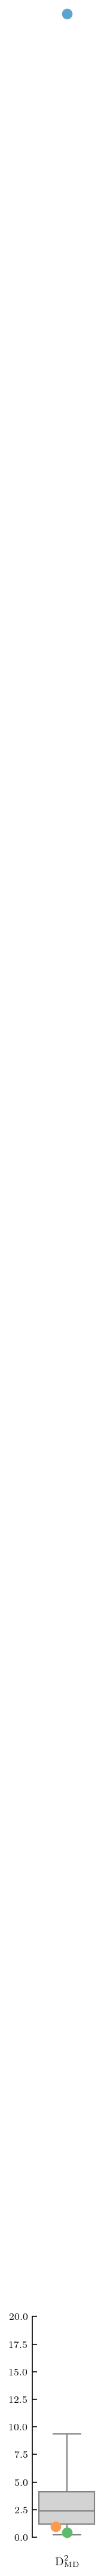

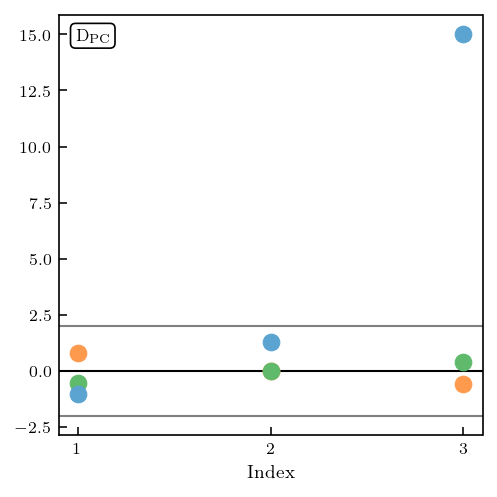

In [14]:
# call the diagnostics here to test before using on number density results
trunc.diagnostics(40, 45)

---

## Calculation of $P(n)$ <a id="calc_p_n"></a>

Now we want to obtain the pressure in terms of the baryon number density $n$, instead of the chemical potential. This means we need to employ the Kohn-Luttinger-Ward formalism mentioned at the top of this notebook. This formalism essentially rewrites the pressure at each order in terms of $\mu_{FG}(n)$, preserving thermodynamic consistency along the way. The code in the `pqcd_reworked.py` file does this for us, order-by-order.

### Setting up $n$ to obtain corresponding $\mu_{FG}(n)$

To pick the proper number density, we will first decide that range and then convert it to the corresponding chemical potential, as the code solves with respect to the quark chemical potential. 

__NOTE__: The warnings that will appear if one attempts to calculate under 0.4 GeV in the quark chemical potential are because this is approximately where $\alpha_{s}(\bar{\Lambda})$ becomes equal to 1.0. This is something make sure cut from our final results, but at present we calculate there since we need, at least for the pointwise mixing approach, data at the same points for both $\chi$EFT and pQCD, and we begin $\chi$EFT from there.

In [15]:
#n = np.linspace(11.2, 16.0, 300) # baryon number density from chiral EFT [fm^-3]
n = np.linspace(0.05, 16.4, 600)
dens = n

# # convert this quark number density first
# n_q = n*3.0  # n_q [fm^-3]

# # convert to GeV^3 for mu_q
# conversion_fm3 = ((1000.0)**(3.0))/((197.33)**(3.0)) # [fm^-3]  (do the opposite of this)
# n_q = n_q/conversion_fm3  # [GeV^3]

# # invert to get mu
# _, mu_n, mu_FG = pqcd.inversion(n_mu=n_q)  # [GeV] # these are quark chemical potentials

# # FG chemical potential
# mU_FG = mu_FG[:,None]   # [GeV] 

Now we will work on setting up the $P(n)$ curve such that we do exactly as above, but now for $P(n)$ instead of $P(\mu)$. This should get us the correct error bands this time around.

In [16]:
n_orders = 3    # Here we examine the case where we have info on two non-trivial orders (1,2)
orders = np.arange(0, n_orders)

# try only using the NLO, N2LO coefficients
excluded = [0]
orders_mask = ~ np.isin(orders, excluded)   # masking orders to exclude them from training

# call the PQCD class from the pqcd_reworked.py file
pqcd_anm = PQCDDens(dens, X=1,Nf=3)

# define the coefficients from the P(n) curve explicitly
coeffs_anm = np.array([pqcd_anm.c_0_n(dens), pqcd_anm.c_1_n(dens), pqcd_anm.c_2_n(dens)]).T  # this is good

/Users/alexandra/Documents/EOSBMM/buqeyenm/notebooks/../src/pqcd_reworked.py:143: RuntimeWarning: invalid value encountered in log
  alpha_s = ((4.0*np.pi)/(self.beta0*ell)) * (1.0 - (2.0*beta1*np.log(ell))/(ell*self.beta0**2.0))


Text(0.5, 0, '$x$')

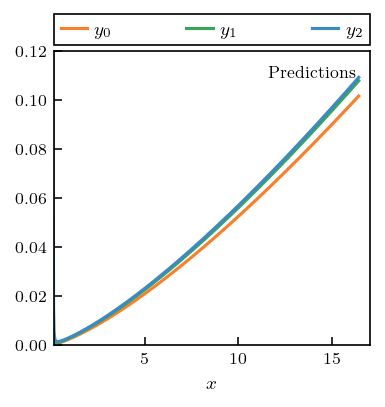

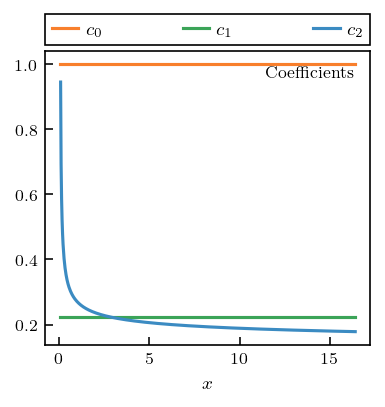

In [17]:
# use the new truncation class
from truncation_error_dens import TruncationDens
trunc_anm = TruncationDens(dens, norders=3, orders=orders, yref=pqcd_anm.yref_dens, \
                   expQ=pqcd_anm.expQ_dens, coeffs=coeffs_anm, mask=orders_mask)

fig, ax = plt.subplots(1, 1, figsize=(2.45, 2.6))

for i, curve in enumerate(trunc_anm.data.T):   # need to check these predictions (what units?)
    ax.plot(dens, curve, label=r'$y_{}$'.format(i), c=colors[i])

ax.text(0.95, 0.95, 'Predictions', ha='right', va='top',
        transform=ax.transAxes)

ax.set_xlim(0.164, 17)
ax.set_ylim(0.0, 0.12)
legend = ax.legend(**top_legend_kwargs)

# Format
ax.set_xlabel(r'$x$')

fig, ax = plt.subplots(1, 1, figsize=(2.45, 2.6))

for i,n in enumerate(orders):
    ax.plot(dens, trunc_anm.coeffs[:, i], label=r'$c_{}$'.format(i), c=colors[i])

ax.text(0.95, 0.95, 'Coefficients', ha='right', va='top',
           transform=ax.transAxes)

legend = ax.legend(**top_legend_kwargs)

# Format
ax.set_xlabel(r'$x$')

In [18]:
dof = 3.0
sd = np.sqrt((dof - 2.0)/dof)
pred_anm, std_anm, underlying_std_anm = trunc_anm.gp_interpolation(center=0.0, dof=dof, sd=sd)

RBF(length_scale=57.1)
0.24918687419445112


RBF(length_scale=57.1)
0.24918687419445112
0.49918621194345014


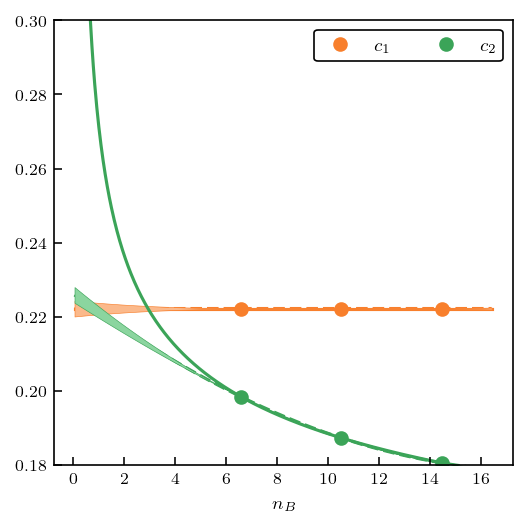

In [19]:
fig, ax = plt.subplots(figsize=(3.4, 3.4), dpi=150)
for i, n in enumerate(orders[1:]):
    ax.plot(dens, pred_anm[:, i], c=colors[i], zorder=i-5, ls='--')
    ax.plot(dens, trunc_anm.coeffs_trunc[:, i], c=colors[i], zorder=i-5)
  #  ax.plot(x, trunc.coeffs[:, i], c=colors[i], zorder=i-5)
    ax.plot(dens[trunc_anm.mask], trunc_anm.coeffs_trunc[trunc_anm.mask, i], c=colors[i], \
            zorder=i-5, ls='', marker='o',
            label=r'$c_{}$'.format(n))
 #   ax.plot(x[trunc.mask], trunc.coeffs[trunc.mask, i], c=colors[i], zorder=i-5, ls='', marker='o',
 #         label=r'$c_{}$'.format(n))
    ax.fill_between(dens, pred_anm[:, i] + 2*std_anm, pred_anm[:, i] - 2*std_anm, zorder=i-5,
                     facecolor=light_colors[i], edgecolor=colors[i], lw=edgewidth, alpha=1)

print(trunc_anm.gp_interp.kernel_)
print(trunc_anm.gp_interp.cov_factor_)
print(np.sqrt(trunc_anm.gp_interp.cov_factor_))

# Format
ax.axhline(1.0*underlying_std_anm, 0, 1, c='gray', zorder=-10, lw=1)
ax.axhline(-1.0*underlying_std_anm, 0, 1, c='gray', zorder=-10, lw=1)
ax.axhline(0, 0, 1, c='k', zorder=-10, lw=1)
ax.set_xlabel(r'$n_{B}$')
ax.tick_params(which='minor', bottom=True, top=False)
ax.set_ylim(0.18, 0.3)
ax.legend(ncol=2, borderaxespad=0.5, borderpad=0.4)

In [20]:
# feed the code the pQCD EOS in KLW form
nB = dens[:,None]
data_0 = pqcd_anm.yref_dens(nB) * pqcd_anm.c_0_n(dens) 
data_1 = pqcd_anm.yref_dens(nB) * (pqcd_anm.c_0_n(dens) + pqcd_anm.c_1_n(dens)*pqcd_anm.expQ_dens(nB))
data_2 = pqcd_anm.yref_dens(nB) * (pqcd_anm.c_0_n(dens) + pqcd_anm.c_1_n(dens)*pqcd_anm.expQ_dens(nB) \
                             + pqcd_anm.c_2_n(dens)*pqcd_anm.expQ_dens(nB)**2.0)

# compile the orders
data_anm = np.array([data_0, data_1, data_2]).T

# feed to the TruncationGP class and get back the truncation errors (excluding c_0)
data_anm, coeffs_anm, std_anm, cov_1_anm = trunc_anm.uncertainties(data=data_anm, \
                                                        expQ=pqcd_anm.expQ_dens, \
                                                                   yref=pqcd_anm.yref_dens, dof=dof, sd=sd, \
                                        excluded=[0], nugget=1e-10)
print(trunc_anm.trunc_gp.coeffs_process.cov_factor_)

RBF(length_scale=57.1)
1e-10
0.24918775350281175


/Users/alexandra/Documents/EOSBMM/buqeyenm/notebooks/../src/pqcd_reworked.py:143: RuntimeWarning: invalid value encountered in log
  alpha_s = ((4.0*np.pi)/(self.beta0*ell)) * (1.0 - (2.0*beta1*np.log(ell))/(ell*self.beta0**2.0))
/Users/alexandra/anaconda3/envs/BUQEYE/lib/python3.9/site-packages/gsum/models.py:1340: RuntimeWarning: invalid value encountered in multiply
  return self.ref(X) * ratio_sum * coeff_mean


In [21]:
# use the same kernel as before (aka the exact same class), but predict at the new points in n (aka, mu_FG)
std_trunc_pn_anm = np.zeros([len(nB), n_orders])
cov_trunc_pn_anm = np.zeros([len(nB), len(nB), n_orders])
for i, n in enumerate(orders):
        _, std_trunc_pn_anm[:,n] = trunc_anm.trunc_gp.predict(nB, order=n, return_std=True, kind='trunc', \
                                                      pred_noise=True)
        _, cov_trunc_pn_anm[:,:,n] = trunc_anm.trunc_gp.predict(nB, order=n, return_std=False, \
                                                        return_cov=True, kind='trunc', pred_noise=True)
        
# print the kernel parameters
print(trunc_anm.trunc_gp.coeffs_process.kernel_)

# mask the inf values in std_trunc_pn_anm (first value never exists)
for j in range(len(orders)):
    for i in range(len(std_trunc_pn_anm)):
        if np.isnan(std_trunc_pn_anm[i,j]) == True or np.isinf(std_trunc_pn_anm[i,j]) == True:
            std_trunc_pn_anm[i,j] = 1e10

RBF(length_scale=57.1)


Text(0.1, 0.9, '$P(n)$ [MeV/fm$^{3}$]')

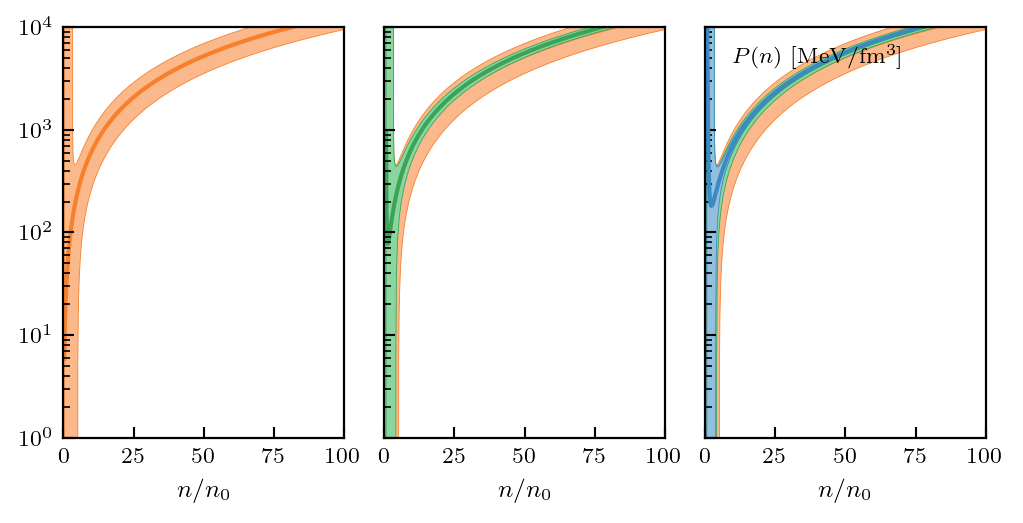

In [22]:
fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(5, 2.5), dpi=200)
conversion = (1000)**4.0/(197.327)**3.0 

# call KLW function for pressure and assign to array
pressure_n_KLW = pqcd_anm.pressure_KLW_check(dens)
corrected_pressure = np.array([pressure_n_KLW["LO"], pressure_n_KLW["NLO"], pressure_n_KLW["N2LO"]]).T

for i, n in enumerate(orders):
    for j in range(i, 3):
        ax = axes.ravel()[j]
        ax.set_xlim(0.0, 100.0)
        ax.set_yscale('log')
        ax.set_ylim(1.0,10000)
        ax.plot(dens/n0, corrected_pressure[:,i]*conversion, zorder=i, c=colors[i])
        ax.fill_between(dens/n0, corrected_pressure[:, i]*conversion + 1.96*std_trunc_pn_anm[:,i]*conversion, \
                        corrected_pressure[:, i]*conversion - 1.96*std_trunc_pn_anm[:,i]*conversion,
                        zorder=i-1, facecolor=light_colors[i], edgecolor=colors[i], lw=edgewidth)
    ax = axes.ravel()[i]
    ax.set_xlabel(r'$n/n_{0}$')
ax.text(0.1, 0.9, r'$P(n)$ [MeV/fm$^{3}$]', ha='left', va='bottom',
           transform=ax.transAxes, fontsize=8)

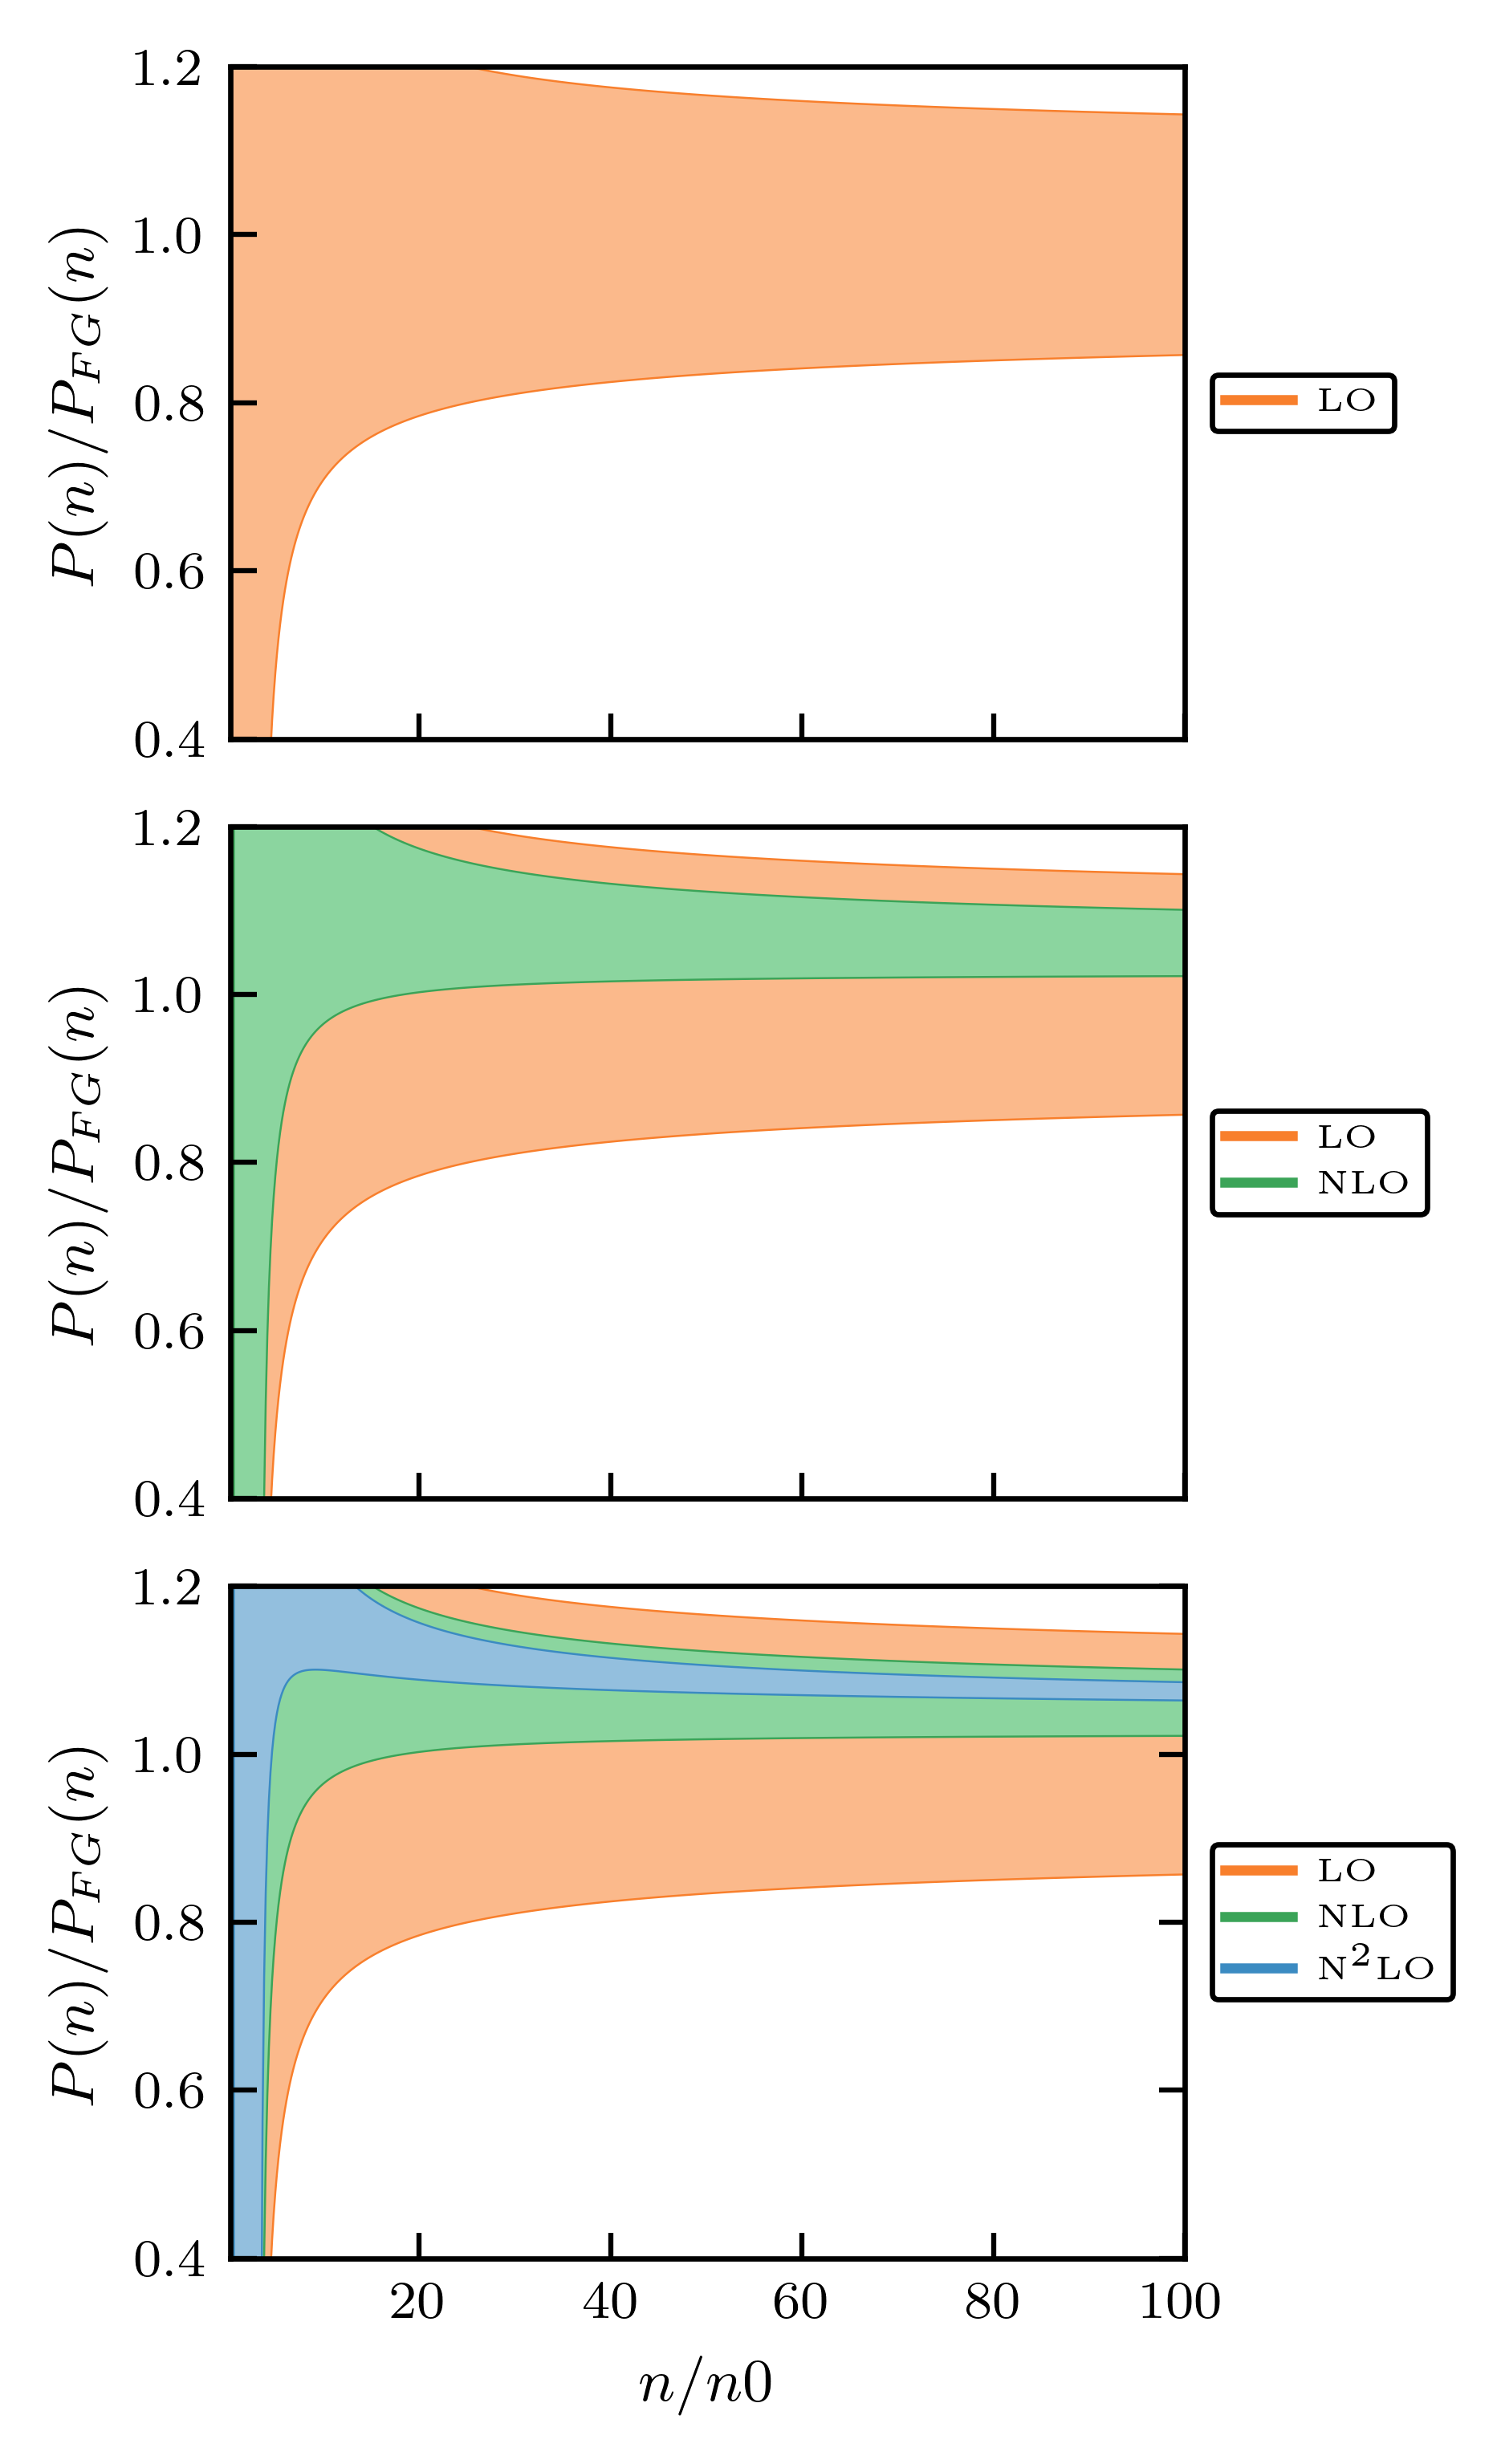

In [23]:
# X = mu_n[:,None]
# X_FG = mu_FG[:,None]  
labels = [r'LO', r'NLO', r'N$^{2}$LO']
labels_original = [r'LO original', r'NLO original', r'N$^{2}$LO original']

fig, axes = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(3,5), dpi=600)

for i,n in enumerate(orders):
    for j in range(i, 3):
        ax = axes.ravel()[j]
        ax.plot(dens/n0, corrected_pressure[:, i]/pqcd_anm.yref_dens(nB), \
                zorder=i-1, c=colors[i], label=labels[i])
        ax.fill_between(dens/n0, (corrected_pressure[:, i] + 1.0*std_trunc_pn_anm[:,i])/pqcd_anm.yref_dens(nB),\
                        (corrected_pressure[:, i] - 1.0*std_trunc_pn_anm[:,i])/pqcd_anm.yref_dens(nB),
                        zorder=i-1, facecolor=light_colors[i], edgecolor=colors[i], lw=edgewidth)
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=5)
    ax = axes.ravel()[i]
    ax.set_ylim(0.4,1.2)
    ax.set_xlim(min(dens)/n0, max(dens)/n0)
    ax.set_ylabel(r'$P(n)/P_{FG}(n)$')
ax.set_xlabel(r'$n/n0$')
ax.tick_params(right=True)

#print(std_trunc_pn[:,2])

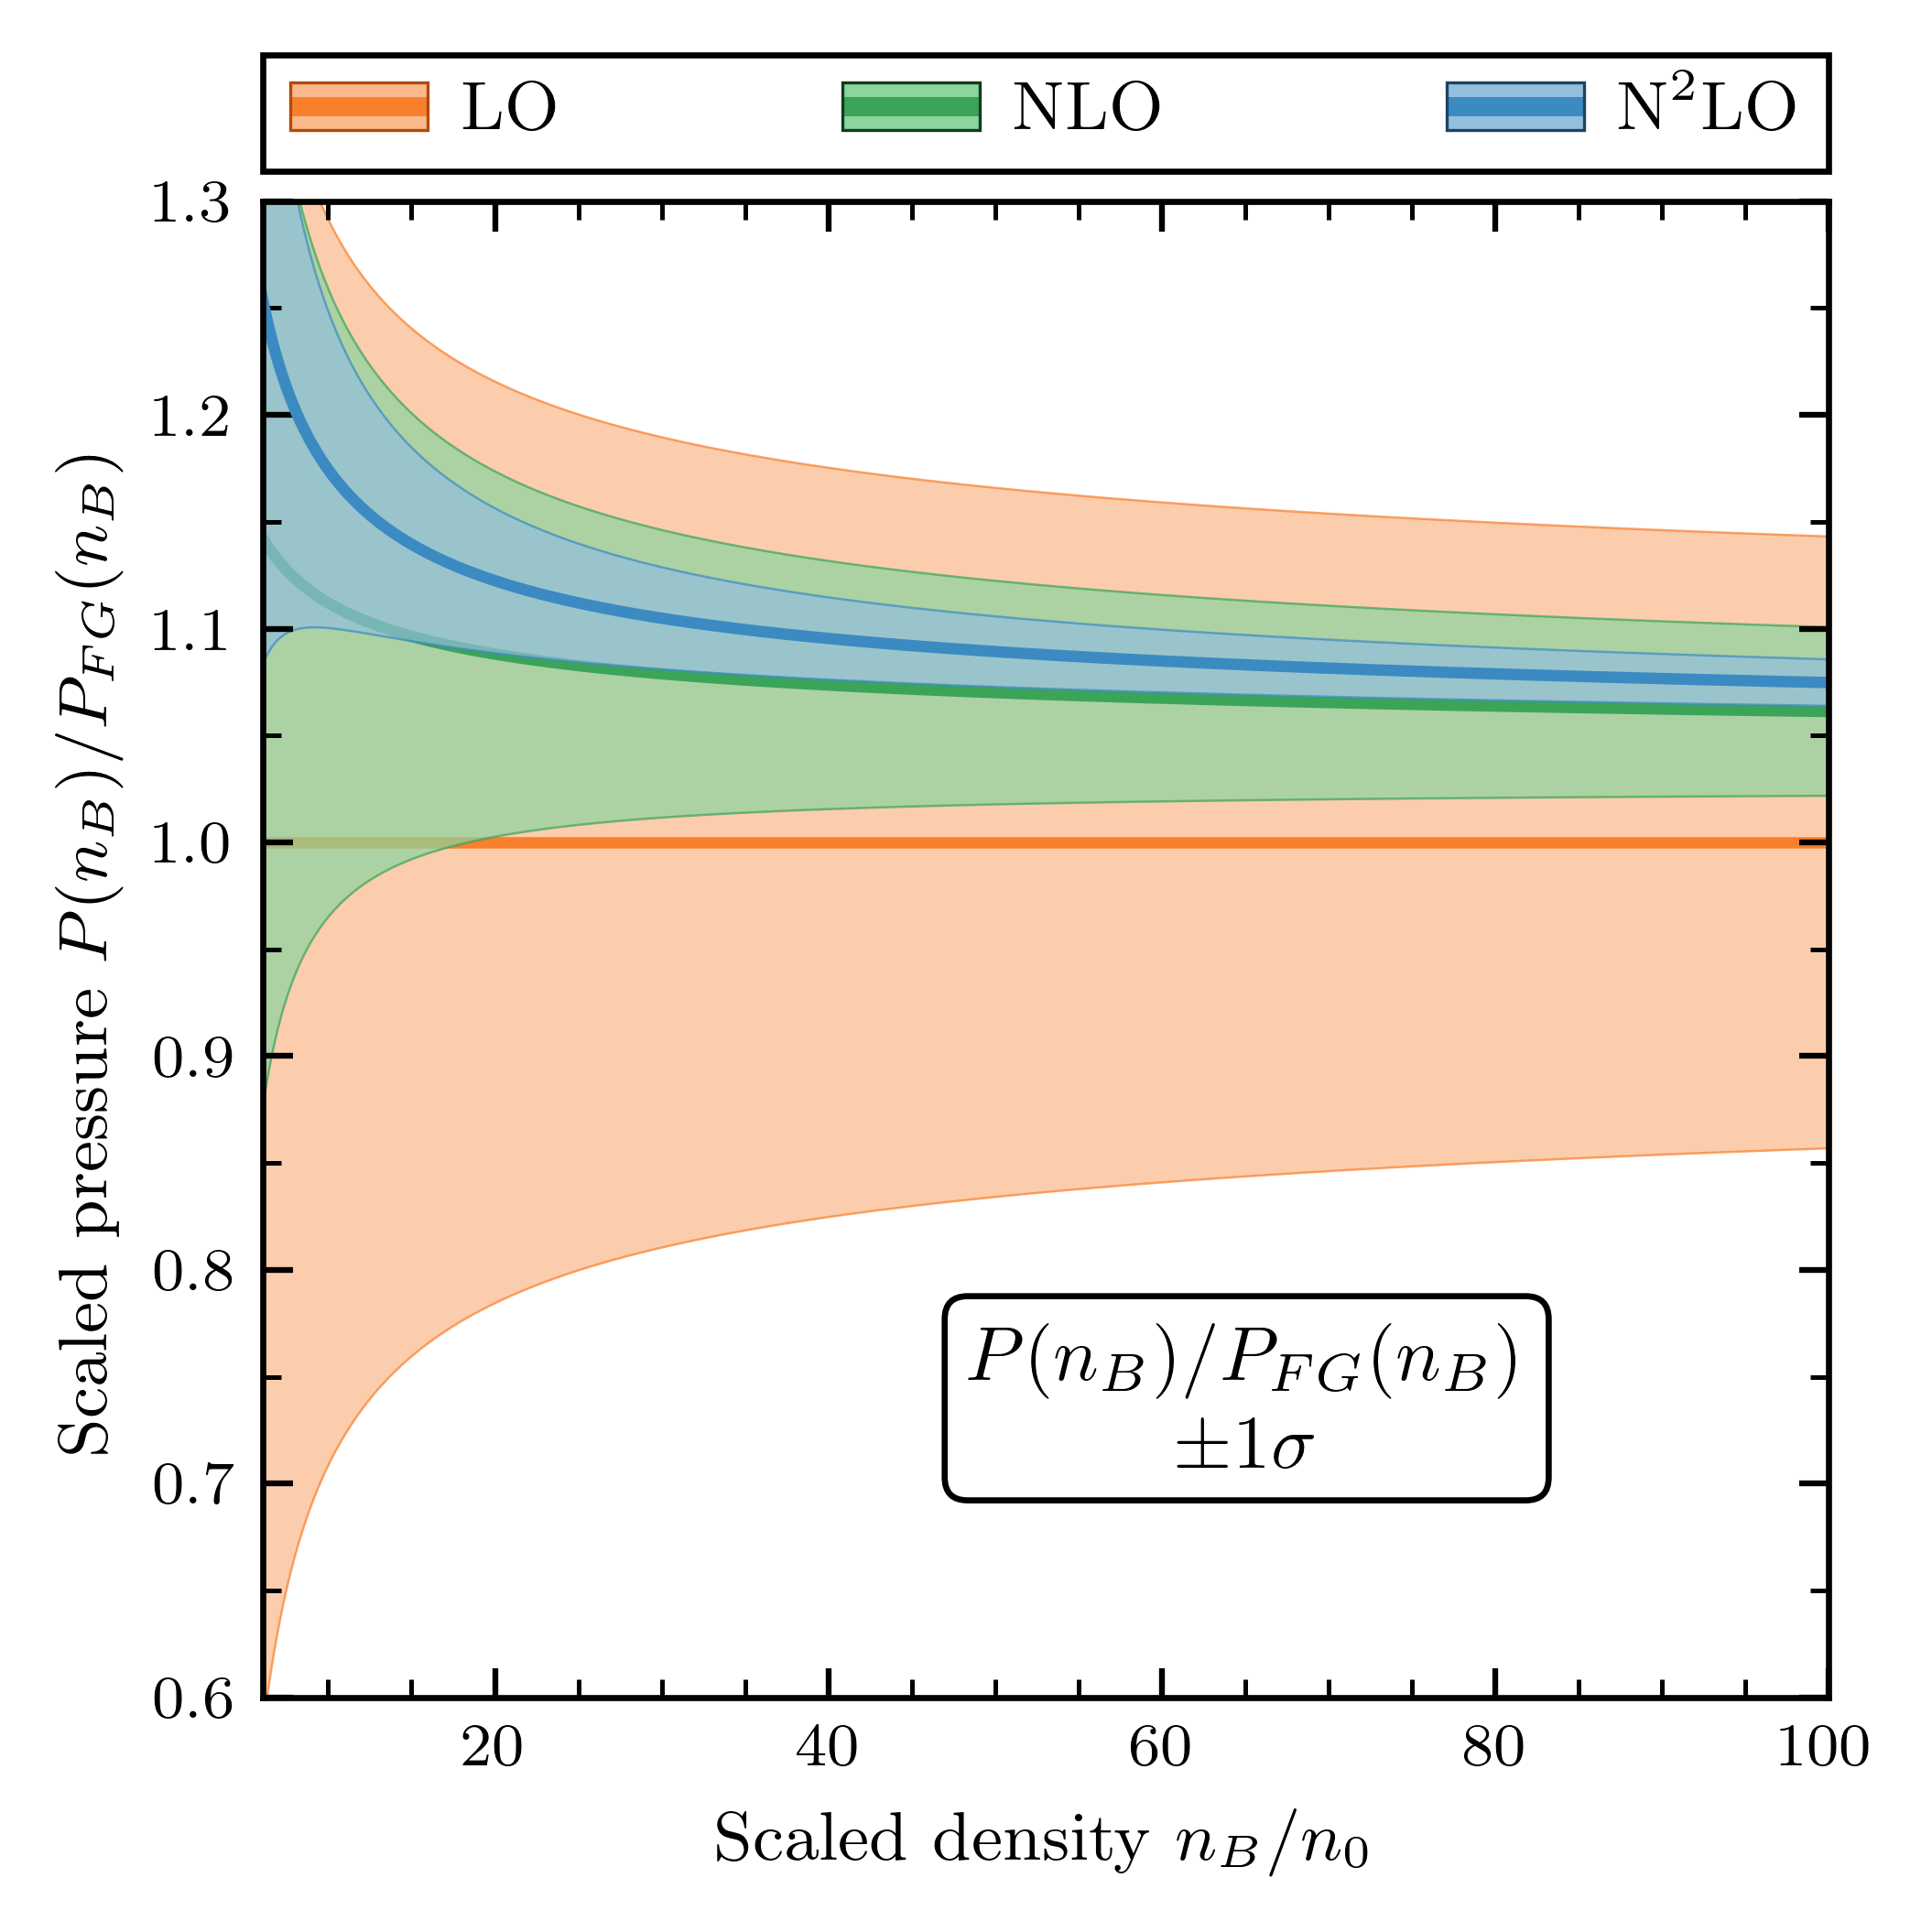

In [24]:
# Fig. 4 in our paper
labels = [r'LO', r'NLO', r'N$^{2}$LO']
labels_original = [r'LO original', r'NLO original', r'N$^{2}$LO original']

fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(3.4, 3.4), dpi=600)
for i in range(3):
    ax.plot(dens/n0, corrected_pressure[:, i]/pqcd_anm.yref_dens(nB), zorder=i, c=colors[i], label=labels[i])
    ax.fill_between(dens/n0, (corrected_pressure[:, i] + 1.0*std_trunc_pn_anm[:,i])/pqcd_anm.yref_dens(nB), \
                    (corrected_pressure[:, i] - 1.0*std_trunc_pn_anm[:,i])/pqcd_anm.yref_dens(nB),
                    zorder=i-1, facecolor=light_colors[i], edgecolor=colors[i], lw=edgewidth, alpha=0.7)
    ax.set_ylim(0.6,1.3)
    ax.set_xlim(1.0/n0, max(dens)/n0)
    ax.set_ylabel(r'Scaled pressure $P(n_B)/P_{FG}(n_B)$')
ax.set_xlabel(r'Scaled density $n_B/n_{0}$')
title = r'''$P(n_B)/P_{FG}(n_B) $
$\pm 1\sigma$'''
ax.text(
    0.45, 0.25, title, transform=ax.transAxes, ha='left', va='top',
    multialignment='center', zorder=10, fontsize=10,
    bbox=dict(facecolor='w', boxstyle='round')
)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(right=True, top=True, which='both')
add_top_order_legend(fig, ax, ax, order_labels, colors, light_colors, dark_colors, )
#fig.savefig('../figures/ANM_Figures/pqcd_pressure_n_NSM.pdf')

In [25]:
# use the checker to make sure things are OK before developing that code
mu_FG = (3.0 * np.pi**2.0 * 3.0 * dens * (197.33/1000.)**3.0 / (pqcd.Nc * pqcd.Nf))**(1.0/3.0)
pressure_check = pqcd_anm.pressure_KLW(mu_FG)
print(pressure_check['N2LO']-corrected_pressure[:,2])  # good it works!

[            nan             nan  0.00000000e+00  1.80411242e-16
 -2.77555756e-17  4.33680869e-18 -8.67361738e-19  1.73472348e-18
  0.00000000e+00  8.67361738e-19  0.00000000e+00  0.00000000e+00
 -4.33680869e-19  0.00000000e+00  2.16840434e-19 -4.33680869e-19
  0.00000000e+00  6.50521303e-19 -2.16840434e-19  0.00000000e+00
  2.16840434e-19 -2.16840434e-19  0.00000000e+00  0.00000000e+00
  4.33680869e-19  0.00000000e+00  0.00000000e+00  0.00000000e+00
  4.33680869e-19  0.00000000e+00 -8.67361738e-19  8.67361738e-19
  8.67361738e-19  1.30104261e-18  4.33680869e-19  4.33680869e-19
  0.00000000e+00  0.00000000e+00 -4.33680869e-19  8.67361738e-19
 -4.33680869e-19  0.00000000e+00  8.67361738e-19 -8.67361738e-19
  0.00000000e+00  8.67361738e-19  0.00000000e+00  0.00000000e+00
 -8.67361738e-19  0.00000000e+00  0.00000000e+00 -8.67361738e-19
 -8.67361738e-19 -8.67361738e-19  0.00000000e+00  0.00000000e+00
 -8.67361738e-19  8.67361738e-19  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -8.67361

Number of points in training set: 3
Number of points in validation set: 3

Training set: 
 [[ 6.5736227 ]
 [10.50417362]
 [14.43472454]]

Validation set: 
 [[ 5.37262104]
 [10.69524207]
 [16.01786311]]
0.49918709268450817
1e-10
Calculated value : 0.15857402495633474
Trained kernel:  RBF(length_scale=57.1)
Scale:  0.44024163497885294
Condition number: 119262.91889333654


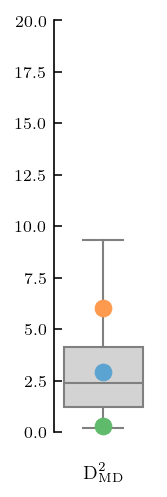

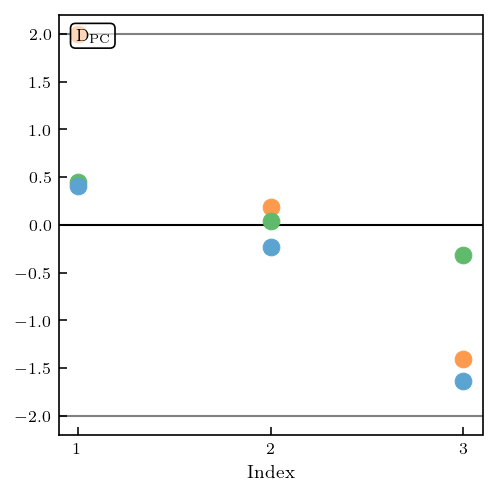

In [26]:
trunc_anm.diagnostics(20,195)

### Investigating $\bar{c}^{2}$

9.0 0.44024163497885294


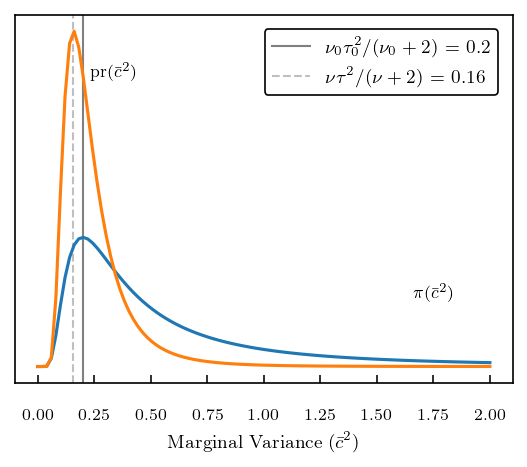

Point estimate:  0.24918775350281175


In [27]:
# extract prior values for the hyperparameters
nu0 = dof
tau0 = sd

df = nu0
tau2 = tau0**2.0

# plot the prior

# Convert to inverse gamma
a = df / 2.
b = df * tau2 / 2.

igam = stats.invgamma(a, scale=b)
cbar_vals = np.linspace(0, 2, 100)

fig, ax = plt.subplots(1, 1, figsize=(3.4, 3))

# Plot curves
ax.plot(cbar_vals, igam.pdf(cbar_vals))

# Add text boxes
#prior
ax.text(0.80, 0.27, r'$\pi$($\bar c^2$)', ha='left', va='top',
           transform=ax.transAxes)

# posterior
ax.text(0.15, 0.87, r'pr($\bar c^2$)', ha='left', va='top',
           transform=ax.transAxes)

# Format plots
line_color = 'gray'
ax.set_yticks([])
ax.set_xlabel(r'Marginal Variance ($\bar c^2$)')
ax.axvline([df * tau2 / (df+2)], 0, 1, c=line_color, zorder=0, lw=1, \
           label=r'$\nu_0\tau_0^2/(\nu_0+2)$ = {}'.format(round(df * tau2 / (df+2), 2)))
ax.tick_params(pad=12)

# extract posterior values for the hyperparameters
nu = trunc_anm.trunc_gp.coeffs_process.df_
tau = trunc_anm.trunc_gp.coeffs_process.scale_

# plot the posterior
print(nu, tau)

# Convert to inverse gamma
a1 = nu / 2.
b1 = nu * tau**2 / 2.

igam1 = stats.invgamma(a1, scale=b1)
cbar_vals = np.linspace(0, 2, 100)

# Plot curves
ax.plot(cbar_vals, igam1.pdf(cbar_vals))
ax.axvline([nu * tau**2 / (nu+2)], 0, 1, c=line_color, zorder=0, lw=1, alpha=0.5, \
           linestyle='dashed', label=r'$\nu\tau^2/(\nu+2)$ = {}'.format(round(nu * tau**2 / (nu+2), 2)))

ax.legend()
plt.show()

print('Point estimate: ', nu*tau**2/(nu-2))

In [28]:
# store the P_FG(n) values, unscaled, for use in BMM later
mU_FG = mu_FG[:,None]
pressure_FG = pqcd_anm.yref(mU_FG)*conversion

# write this to a file (uncomment to save)
if dens.size >= 600:
    np.savez('../data/eos_data/pqcd_fg_data_NSM', density=dens, dens_scaled=dens/n0, mean=pressure_FG)
else:
    print('Not saved.')

In [29]:
# save scaled results in an npz file
mean_pressure_scaled = np.zeros([len(dens), 3])
std_pressure_scaled = np.zeros([len(dens), 3])
cov_pressure_scaled = np.zeros([len(dens), len(dens), 3])

scale = pqcd_anm.yref(mU_FG)

for i in range(3):
    mean_pressure_scaled[:,i] = corrected_pressure[:,i]/pqcd_anm.yref(mU_FG)
    std_pressure_scaled[:,i] = std_trunc_pn_anm[:,i]/pqcd_anm.yref(mU_FG)

for i in range(3):
    for j in range(len(dens)):
        for k in range(len(dens)):
            cov_pressure_scaled[j,k,i] = cov_trunc_pn_anm[j,k,i]/(scale[j]*scale[k])

#write this to a file (uncomment to save)
if dens.size >= 600:
#     np.savez('../data/eos_data/pressure_pqcd_data_scaled_NSM', density=dens, dens_scaled=dens/n0, mean=mean_pressure_scaled, std_dev=std_pressure_scaled, \
#              cov=cov_pressure_scaled)
    # open the file here and check it
    npzfile = np.load('../data/eos_data/pressure_pqcd_data_scaled_NSM.npz')
    npzfile.files

    print(npzfile['density'].shape, npzfile['dens_scaled'].shape, npzfile['mean'].shape, npzfile['std_dev'].shape, npzfile['cov'].shape)

    print(np.sqrt(np.diag(cov_pressure_scaled[:,:,2])) - std_pressure_scaled[:,2])
else:
    print('Not saved.')

(600,) (600,) (600, 3) (600, 3) (600, 600, 3)
[            nan             nan             inf             inf
             inf             inf             inf             inf
             inf             inf             inf             inf
             inf             inf             inf             inf
             inf             inf  0.00000000e+00 -2.22044605e-16
 -1.11022302e-16  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -5.55111512e-17  0.00000000e+00  5.55111512e-17
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -2.77555756e-17
 -2.77555756e-17  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  2.77555756e-17
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -1.38777878e-17  0.00000000e+00  0.00000000e+00
  1.38777878e-17  0.00000000e+00 -1.38777878e-17  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -1.38777878e-17  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000

In [30]:
# print the whole thing
print('Results at 100*n0:')
print('LO:',(corrected_pressure[:, 0]/pqcd_anm.yref_dens(nB))[-1])
print('NLO:',(corrected_pressure[:, 1]/pqcd_anm.yref_dens(nB))[-1])
print('N2LO:',(corrected_pressure[:, 2]/pqcd_anm.yref_dens(nB))[-1]) 

Results at 100*n0:
LO: 1.0
NLO: 1.0612489526361948
N2LO: 1.0747729349080195


In [39]:
# use the inversion backwards to obtain number density
mu_val = 0.7 # GeV, mu_q (want to try to reach this!)
n_val_1 = 3.28  # 20n0 value in nB
n_val_2 = 6.56  # 40n0 value in nB

# n_mu => needs to be in n_q => 3.28 fm^-3 in nB => 3.28*3 = 9.84
_, mu_n_1 = pqcd.n_convert_mu(np.array([n_val_1]))
_, mu_n_2 = pqcd.n_convert_mu(np.array([n_val_2]))

print(mu_n_1, mu_n_2)

[0.70539933] [0.87375692]


---

## Relative error calculation (Table I) <a id="calc_rel_err"></a>

We wish to find the place in the pQCD $P(n)$ result that matches the relative error in $\chi$EFT at the densities $1.5n_{0}$, $1.75n_{0}$, and $2n_{0}$. This is done below by importing the chiral data and comparing to the pQCD results calculated in the above sections of this notebook.

In [31]:
# # import chiral EFT data
# n0 = 0.164
# chiral_result = np.load('../data/eos_data/pressure_chiral_data_scaled_2n0.npz')

# # interpolate to obtain bands at exactly the required densities
# chiral_interp = interp1d(chiral_result['density'], chiral_result['mean'][:,3], \
#                          kind='cubic', fill_value='extrapolate')
# chiral_low_interp = interp1d(chiral_result['density'], \
#                              chiral_result['mean'][:,3]-1.0*chiral_result['std_dev'][:,3], \
#                              kind='cubic', fill_value='extrapolate')
# chiral_hi_interp = interp1d(chiral_result['density'], \
#                             chiral_result['mean'][:,3]+1.0*chiral_result['std_dev'][:,3], \
#                            kind='cubic', fill_value='extrapolate')

# # evaluate exactly at required densities
# chi_mean_15 = chiral_interp(1.5*n0)
# chi_low_15 = chiral_low_interp(1.5*n0)
# chi_hi_15 = chiral_hi_interp(1.5*n0)

# chi_mean_175 = chiral_interp(1.75*n0)
# chi_low_175 = chiral_low_interp(1.75*n0)
# chi_hi_175 = chiral_hi_interp(1.75*n0)

# chi_mean_2 = chiral_interp(2.0*n0)
# chi_low_2 = chiral_low_interp(2.0*n0)
# chi_hi_2 = chiral_hi_interp(2.0*n0)

# # store results and print
# chiral_cutoff_15 = {
#     'mean': chi_mean_15,
#     'lower': chi_mean_15 - chi_low_15,
#     'upper': chi_hi_15 - chi_mean_15
# }

# chiral_cutoff_15 = {
#     'mean': chi_mean_15,
#     'lower': chi_mean_15 - chi_low_15,
#     'upper': chi_hi_15 - chi_mean_15
# }


# chiral_cutoff_175 = {
#     'mean': chi_mean_175,
#     'lower': chi_mean_175 - chi_low_175,
#     'upper': chi_hi_175 - chi_mean_175
# }

# chiral_cutoff_2 = {
#     'mean': chi_mean_2,
#     'lower': chi_mean_2 - chi_low_2,
#     'upper': chi_hi_2 - chi_mean_2
# }

# print('At 1.5*n0, chiral EFT yields the values: \n', chiral_cutoff_15)
# print('\nAt 1.75*n0, chiral EFT yields the values: \n', chiral_cutoff_175)
# print('\nAt 2.0*n0, chiral EFT yields the values: \n', chiral_cutoff_2)

# # now we compare to pQCD EOS values
# # print relative error there
# rel_err_15 = chiral_cutoff_15['upper']/chiral_cutoff_15['mean']
# rel_err_175 = chiral_cutoff_175['upper']/chiral_cutoff_175['mean']
# rel_err_2 = chiral_cutoff_2['upper']/chiral_cutoff_2['mean']

# print('\nRelative error at 1.5n0: ', rel_err_15, 'and % error: ', rel_err_15*100.)
# print('Relative error at 1.75n0: ', rel_err_175, 'and % error: ', rel_err_175*100.)
# print('Relative error at 2.0n0: ', rel_err_2, 'and % error: ', rel_err_2*100.)

# pqcd_rel_interp = interp1d(dens[12:], std_trunc_pn[12:, 2]/corrected_pressure[12:,2], \
#                            kind='cubic', fill_value='extrapolate')
# # pqcd_rel_interp = interp1d(dens[70:], std_trunc_pn[70:, 2]/corrected_pressure[70:,2], \
# #                            kind='cubic', fill_value='extrapolate')  # for X = 0.5, x0 = 3.0
# pqcd_rel_dens_15 = fsolve(lambda n : rel_err_15 - pqcd_rel_interp(n), x0 = 1.0, xtol=1e-08)[0]
# pqcd_rel_dens_175 = fsolve(lambda n : rel_err_175 - pqcd_rel_interp(n), x0 = 1.0, xtol=1e-08)[0]
# pqcd_rel_dens_2 = fsolve(lambda n : rel_err_2 - pqcd_rel_interp(n), x0 = 1.0, xtol=1e-08)[0]

# # print the results
# print('\npQCD density location for equal relative error at 1.5n0: ', pqcd_rel_dens_15, '[fm^-3]')
# print('pQCD density in terms of n0: ', pqcd_rel_dens_15/n0)
# print('Relative error at this exact point: ', pqcd_rel_interp(pqcd_rel_dens_15))
# print(pqcd_rel_interp(pqcd_rel_dens_15))
# print(rel_err_15 - pqcd_rel_interp(pqcd_rel_dens_15))

# print('\npQCD density location for equal relative error at 1.75n0: ', pqcd_rel_dens_175, '[fm^-3]')
# print('pQCD density in terms of n0: ', pqcd_rel_dens_175/n0)
# print('Relative error at this exact point: ', pqcd_rel_interp(pqcd_rel_dens_175))
# print(pqcd_rel_interp(pqcd_rel_dens_175))
# print(rel_err_175 - pqcd_rel_interp(pqcd_rel_dens_175))

# print('\npQCD density location for equal relative error at 2.0n0: ', pqcd_rel_dens_2, '[fm^-3]')
# print('pQCD density in terms of n0: ', pqcd_rel_dens_2/n0)
# print('Relative error at this exact point: ', pqcd_rel_interp(pqcd_rel_dens_2))
# print(pqcd_rel_interp(pqcd_rel_dens_2))
# print(rel_err_2 - pqcd_rel_interp(pqcd_rel_dens_2))

---

## Speed of sound calculation, $c_{s}^{2}(n)$ <a id="cs2"></a>

Analytically, this can be expressed as

$$
c_{s}^{2} = \frac{\partial P}{\partial \varepsilon} = \frac{\partial P}{\partial n}\left[\frac{\partial \varepsilon}{\partial n}\right]^{-1} = \frac{1}{\mu} \frac{\partial P}{\partial n}
$$

We can obtain both of these quantities quite easily, and we can even, instead of taking the derivative of $P$ with respect to $n$, use the logarithmic derivative form of the above equation, which reads as

$$
c_{s}^{2} = \frac{d\ln{\mu}}{d\ln{n}} = n \frac{\partial \ln\mu(n)}{\partial n}.
$$

Here, we'll need the values of $n$, $\ln\mu$, and $\frac{\partial \ln \mu}{\partial n}$, so let's check to see how convenient it is to obtain these with our new KLW inversion technique. 

For the speed of sound from the GP, we'll eventually need this expression for the energy density,

$$
\varepsilon(n) = n \left[\frac{\varepsilon(n_{i})}{n_{i}} + \int_{n_{i}}^{n}\frac{P(n')}{n'^{2}} dn' \right]
$$

where we are integrating the results from $P(n)$ KLW calculations, and using an initial density to make sure that we obtain the proper boundary condition for the integral. For us, we find that integrating backward using a boundary condition from pQCD established at $100n_{0}$ is the optimal way to do this calculation.

In [33]:
# calculate the speed of sound in the same manner as 
# done for the mixed model to find any inconsistencies
from eos_utils import speed_of_sound
import scipy.integrate as scint
import scipy.interpolate as scinterp

hbarc = 197.327 # MeV fm

# cut the pressure linspace from 0.05,16.0 to 11.48,16.4 or so
# (higher-order effects not too strong >= 70n0)
cs2_cut = np.where([i >= 11.48 for i in dens])[0][0]  # density comparison to n0 = 0.164 fm^-3

In [127]:
# function to calculate the boundary condition
def boundary_conditions(dens, pres_dict, index=0): 
    
    # constants
    hbarc = 197.327 # Mev fm
    
    # unpack dictionary
    pres_FG = pres_dict['FG']
    pres_NLO = pres_dict['NLO']
    pres_N2LO = pres_dict['N2LO']
    
    # set up new dictionary for eps(n) BCs
    edens_FG = dict()
    edens_NLO = dict()
    edens_N2LO = dict()
    
    # make mu_FG array from the selected density array
    n_q = dens*3.0  # n_q [fm^-3]

    # convert to GeV^3 for mu_q
    conversion_fm3 = ((1000.0)**(3.0))/((hbarc)**(3.0)) # [fm^-3]  (do the opposite of this)
    n_q = n_q/conversion_fm3  # [GeV^3]

    # invert to get mu (should be using Nf=3)
    pqcd_anm = PQCD(X=1, Nf=3)
    _, mu_n, mu_FG = pqcd_anm.inversion(n_mu=n_q)  # [GeV] # these are quark chemical potentials
    print(n_q.shape)
    mU_FG = mu_FG[:, None]
    
    # FG BCs
    edens_FG['mean'] = 3.0 * pres_dict_FG['mean'][index] #((3.0 / (2 * np.pi**2.0)) * 
    #(3.0 * np.pi**2.0 * dens/2.0)**(4.0/3.0) * hbarc)[index]
    edens_FG['lower'] = (dens*3*1000.*mu_FG - (pres_dict_FG['mean']-pres_dict_FG['std_dev']))[index]
    edens_FG['upper'] = (dens*3*1000.*mu_FG - (pres_dict_FG['mean']+pres_dict_FG['std_dev']))[index]
    
    # NLO BCs
    edens_NLO['mean'] = ((pqcd_anm.mu_1(mU_FG)[:,0]*1000.) * 3.0 * dens - \
                         (pres_dict_NLO['mean'] - pres_dict_FG['mean']))[index]
    edens_NLO['lower'] = ((pqcd_anm.mu_1(mU_FG)[:,0]*1000.) * 3.0 * dens \
    - ((pres_dict_NLO['mean'] - pres_dict_FG['mean']) - \
       (pres_dict_NLO['std_dev']-pres_dict_FG['std_dev'])))[index]
    edens_NLO['upper'] = ((pqcd_anm.mu_1(mU_FG)[:,0]*1000.) * 3.0 * dens \
    - ((pres_dict_NLO['mean'] - pres_dict_FG['mean']) + \
       (pres_dict_NLO['std_dev']-pres_dict_FG['std_dev'])))[index]
    
    # N2LO BCs
    edens_N2LO['mean'] = ((pqcd_anm.mu_2(mU_FG)[:,0]*1000.) * 3.0 * dens - \
                          (pres_dict_N2LO['mean'] - pres_dict_NLO['mean']))[index]
    
    edens_N2LO['lower'] = ((pqcd_anm.mu_2(mU_FG)[:,0]*1000.) * 3.0 * dens - \
                           ((pres_dict_N2LO['mean'] - pres_dict_NLO['mean']) - \
                            (pres_dict_N2LO['std_dev']-pres_dict_NLO['std_dev'])))[index]
   
    edens_N2LO['upper'] = ((pqcd_anm.mu_2(mU_FG)[:,0]*1000.) * 3.0 * dens - \
                           ((pres_dict_N2LO['mean'] - pres_dict_NLO['mean']) + \
                            (pres_dict_N2LO['std_dev']-pres_dict_NLO['std_dev'])))[index]
        
    # add corrections to single out each order
    edens_NLO['mean'] += edens_FG['mean']
    edens_NLO['lower'] += edens_FG['lower']
    edens_NLO['upper'] += edens_FG['upper']
    
    edens_N2LO['mean'] += edens_NLO['mean']
    edens_N2LO['lower'] += edens_NLO['lower']
    edens_N2LO['upper'] += edens_NLO['upper']

    # combine into dictionary and return
    edens_dict = {
        'FG': edens_FG,
        'NLO': edens_NLO,
        'N2LO': edens_N2LO
    }
    
    print(mu_n[-1])
    print(mu_FG[-1])
    
    return mu_FG, mU_FG, edens_dict

In [147]:
# dictionary of dictionary of pressures
pres_dict_FG = {
    'mean': corrected_pressure[cs2_cut:,0]*conversion,
    'std_dev': std_trunc_pn_anm[cs2_cut:,0]*conversion
}
pres_dict_NLO = {
    'mean': corrected_pressure[cs2_cut:,1]*conversion,
    'std_dev': std_trunc_pn_anm[cs2_cut:,1]*conversion
}

pres_dict_N2LO = {
    'mean': corrected_pressure[cs2_cut:,2]*conversion,
    'std_dev': std_trunc_pn_anm[cs2_cut:,2]*conversion
}

# total dictionary of dictionaries
pres_dict = {
    'FG': pres_dict_FG,
    'NLO': pres_dict_NLO,
    'N2LO': pres_dict_N2LO
}

# run the boundary condition function
mu_cs2_FG, mU_cs2_FG, edens_dict = boundary_conditions(dens[cs2_cut:], pres_dict, index=-1)
print('Boundary condition values for BMM later: \n', edens_dict['N2LO'])
print('Corresponding pressure values: \n', (pres_dict['N2LO']['mean']-pres_dict['N2LO']['std_dev'])[-1], \
      pres_dict['N2LO']['mean'][-1], (pres_dict['N2LO']['mean']+pres_dict['N2LO']['std_dev'])[-1])

# run speed of sound and plot
dens_cs2, cs2_FG, cs2_log_FG, edens_FG, mu_cs2_FG = \
speed_of_sound(dens[cs2_cut:], pres_dict_FG, edens_dict['FG'], integrate='backward')
_, cs2_NLO, cs2_log_NLO, edens_NLO, mu_cs2_NLO = \
speed_of_sound(dens[cs2_cut:], pres_dict_NLO, edens_dict['NLO'], integrate='backward')
_, cs2_N2LO, cs2_log_N2LO, edens_N2LO, mu_cs2_N2LO = \
speed_of_sound(dens[cs2_cut:], pres_dict_N2LO, edens_dict['N2LO'], integrate='backward')

(181,)
1.1658394809385524
1.0753942526192781
Boundary condition values for BMM later: 
 {'mean': 43656.43786424639, 'lower': 43797.05114920654, 'upper': 43509.38929930987}
Corresponding pressure values: 
 14073.430669116362 14217.261594064697 14361.092519013033


In [153]:
edens_anchor = pqcd.anchor_point_edens(samples=pres_dict_N2LO['mean'], anchor=16.4)
print(edens_anchor)  # check against the other code!

pQCD settings: X = 1; Nf = 3
[43653.22022426]


The thermodynamic identity:

$$
\varepsilon = n\mu - P
$$

but $n$ determines $\mu$, so $\varepsilon$ must change.

The thermodynamic identity dictates that for every same n, the epsilon will decrease when pressure increases, to compensate for this change when we are changing n and pressure. However, n and mu_FG should adjust, but they're decided together, so the only thing that can change will be epsilon. This might not be OK, but we'll have to see. For now, it's our only option.

Now we plot our results from the speed of sound calculation above.

FG endpoint: 0.3333327154440212
NLO endpoint: 0.3307738020954502
N2LO endpoint 0.32362326290328836


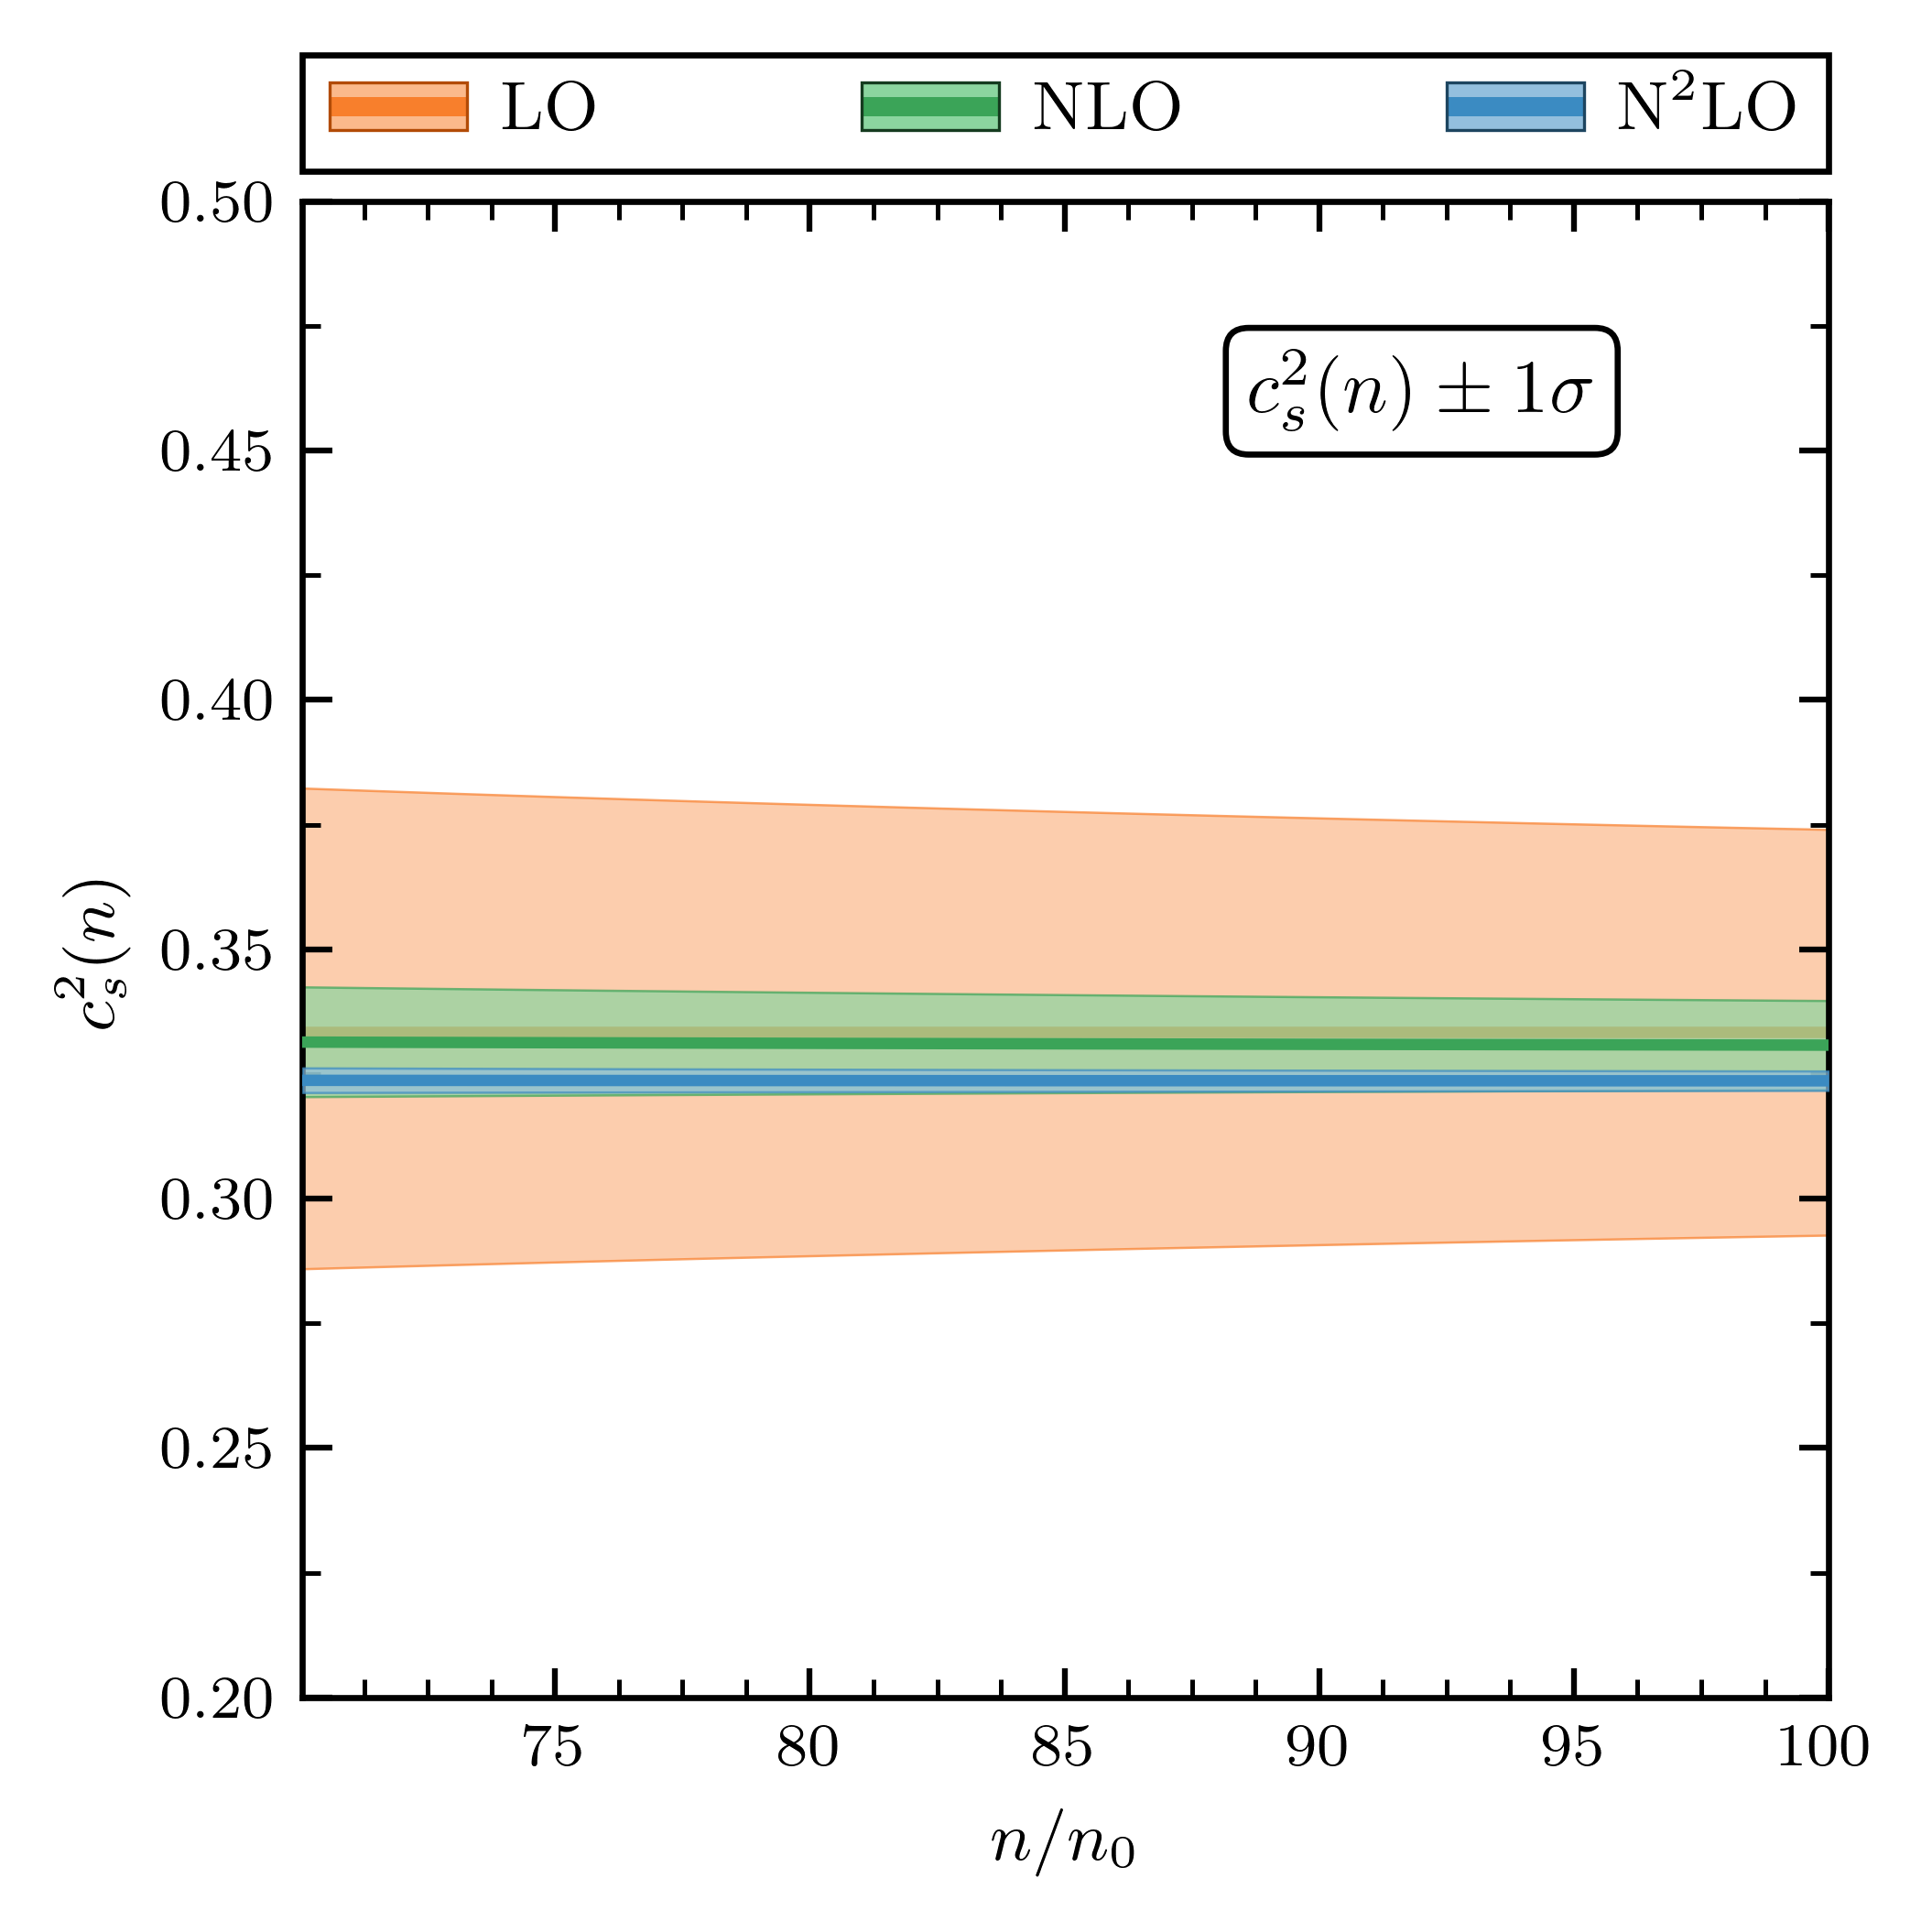

In [135]:
# Fig. 5 from our paper
fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(3.4, 3.4), dpi=600)
ax.axhline(y=(1.0/3.0), color='grey', linestyle='dotted', zorder=-1, alpha=0.2)
ax.plot(dens_cs2/n0, cs2_log_FG['mean'], c=colors[0], zorder=1)
ax.fill_between(dens_cs2/n0, cs2_log_FG['lower'], cs2_log_FG['upper'],
                    zorder=0, facecolor=light_colors[0], edgecolor=colors[0], lw=edgewidth, alpha=0.7)
ax.plot(dens_cs2/n0, cs2_log_NLO['mean'], c=colors[1], zorder=3)
ax.fill_between(dens_cs2/n0, cs2_log_NLO['lower'], cs2_log_NLO['upper'],
                    zorder=2, facecolor=light_colors[1], edgecolor=colors[1], lw=edgewidth, alpha=0.7)
ax.plot(dens_cs2/n0, cs2_log_N2LO['mean'], c=colors[2], zorder=5)
ax.fill_between(dens_cs2/n0, cs2_log_N2LO['lower'], cs2_log_N2LO['upper'],
                    zorder=4, facecolor=light_colors[2], edgecolor=colors[2], lw=edgewidth, alpha=0.7)

ax.set_ylim(0.2,0.5)
ax.set_xlim(min(dens_cs2/n0), 100.0)
ax.set_ylabel(r'$c_{s}^{2}(n)$')
ax.set_xlabel(r'$n/n_{0}$')
title = r'$c_{s}^{2}(n) \pm 1\sigma$'
ax.text(
    0.62, 0.90, title, transform=ax.transAxes, ha='left', va='top',
    multialignment='center', zorder=10, fontsize=10,
    bbox=dict(facecolor='w', boxstyle='round')
)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(right=True, top=True, which='both')
add_top_order_legend(fig, ax, ax, order_labels, colors, light_colors, dark_colors)
#fig.savefig('pqcd_cs2n.png')
print('FG endpoint:', cs2_log_FG['mean'][-1])
print('NLO endpoint:', cs2_log_NLO['mean'][-1])
print('N2LO endpoint', cs2_log_N2LO['mean'][-1])

---

### Save the speed of sound data for the GP package

Now we can save this data to compare to the speed of sound calculated from the mixed model in both BMM approaches.

In [36]:
# saving speed of sound (uncomment to save)
if dens[0] == 1.0:
    print('yo')
    np.savez('../data/eos_data/pqcd_cs2_NSM.npz', density=dens, mean=cs2_N2LO['mean'], \
             lower=cs2_N2LO['lower'], upper=cs2_N2LO['upper'])
    # test viewing
    npzfile = np.load('../data/eos_data/pqcd_cs2_NSM.npz')
    npzfile.files
elif dens[0] == 0.05:
    print('here')
    np.savez('../data/eos_data/pqcd_cs2_NSM.npz', density=dens_cs2, mean=cs2_log_N2LO['mean'], \
             lower=cs2_log_N2LO['lower'], upper=cs2_log_N2LO['upper']) 
else:
    print('Not saved.')

here


---

Now we have completed our pQCD analysis and can move on to our pointwise and correlated model mixing approaches!

Created by: Alexandra Semposki, 
14 March 2024